# ANÁLISIS INTERNO: MINERÍA DE DATOS, TÉCNICAS PLN Y VISUALIZACIONES

### 1. INSTALACIONES E IMPORTACIÓN DE LIBRERÍAS:

In [1]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


 Importa las librerías necesarias para el análisis de texto:
 
- pandas: manipulación y análisis de datos.
- matplotlib.pyplot: creación de gráficos y visualizaciones.
- ast: conversión de cadenas con estructuras de Python (listas, diccionarios, etc.) en objetos reales.
- collections.Counter: recuento de frecuencias de palabras y otros elementos.
- re: expresiones regulares para limpieza y búsqueda de texto.
- nltk: herramientas para el procesamiento del lenguaje natural.
- sent_tokenize (NLTK): segmentación del texto en oraciones.
- word_tokenize (NLTK): tokenización del texto en palabras.
- stopwords (NLTK): eliminación de palabras vacías.
- ngrams (NLTK): generación de secuencias de n palabras consecutivas (bigramas, trigramas, etc.).
- PySentimiento: análisis automático de sentimientos mediante un modelo Transformer (BETO/BERT para español).

In [2]:
import pandas as pd


import matplotlib.pyplot as plt

#importar librerías de 
import ast
from collections import Counter
import re

# Importar librerías de NLTK para el procesamiento de texto
from nltk.tokenize import sent_tokenize
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

#Importar librerías de sentimiento
from pysentimiento import create_analyzer




[nltk_data] Downloading package punkt to /Users/maca/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/maca/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/maca/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 2. IMPORTAR CORPUS CREADO TRAS LA FASE DE LIMPIEZA

In [3]:
df_corpus_limpio = pd.read_csv("corpus_limpio_final.csv")
df_corpus_limpio.head(2)

,id_articulo,fecha,hora,zona_horaria,titulo,autor,subtitulo,url,palabra_clave,cuerpo_noticia,longitud_cuerpo,entidades_detectadas,n_entidades,periodo_fase
0,1,2011-01-23,07:02:00,CET,La llama que incendió Túnez,Juan Miguel Muñoz,La inmolación del vendedor de frutas Mohamed B...,https://elpais.com/diario/2011/01/23/domingo/1...,Mohamed Bouazizi,La llama que incendió Túnez La inmolación del ...,21592,"['Ben Ali', 'Mohamed Bouazizi', 'RCD', 'Rachid...",8,Caída del régimen
1,2,2011-01-17,15:23:00,CET,Un egipcio y un mauritano se queman a lo bonzo,NaN,Se suman un argelino y a otros dos tunecinos q...,https://elpais.com/internacional/2011/01/17/ac...,Mohamed Bouazizi,Un egipcio y un mauritano se queman a lo bonzo...,5781,"['Ben Ali', 'Mohamed Bouazizi', 'Túnez']",3,Caída del régimen


2.1. CREAR CORPUS DE ANÁLISIS

In [4]:
df_analisis = df_corpus_limpio.copy()

In [5]:
df_analisis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_articulo           126 non-null    int64 
 1   fecha                 126 non-null    object
 2   hora                  126 non-null    object
 3   zona_horaria          126 non-null    object
 4   titulo                126 non-null    object
 5   autor                 75 non-null     object
 6   subtitulo             101 non-null    object
 7   url                   126 non-null    object
 8   palabra_clave         126 non-null    object
 9   cuerpo_noticia        126 non-null    object
 10  longitud_cuerpo       126 non-null    int64 
 11  entidades_detectadas  126 non-null    object
 12  n_entidades           126 non-null    int64 
 13  periodo_fase          126 non-null    object
dtypes: int64(3), object(11)
memory usage: 13.9+ KB


2.3. TRANSFORMACIONES DEL CORPUS PARA EL ANÁLISIS

- FECHA: Pasar la fecha a formato datetime

In [6]:
print(df_analisis['fecha'].iloc[0])

2011-01-23


In [7]:
df_analisis['fecha'] = pd.to_datetime(df_analisis['fecha'], format='%Y-%m-%d')
print(df_analisis['fecha'].dtype) 

datetime64[ns]


- CAMPO ENTIDADES: transformar a lista y comprobación.

In [8]:
df_analisis['entidades_detectadas'] = df_analisis['entidades_detectadas'].apply(ast.literal_eval)
print(type(df_analisis['entidades_detectadas'].iloc[0]))


<class 'list'>


- CAMPO UNIFICADO: Compuesto de título + subtítulo + cuerpo de la noticia

In [9]:
def texto_combinado(row):
    partes = [row['titulo'], row['subtitulo'], row['cuerpo_noticia']]
    return " ".join(str(p) for p in partes if pd.notna(p))

df_analisis['texto_análisis'] = df_analisis.apply(texto_combinado, axis=1)

## 3. Visualizaciones

In [10]:
# ============================================================
# PALETA DE COLORES DEL PROYECTO 
# ============================================================
PALETA_FASES = {
    "Fase de protestas": "#E8877D",
    "Caída del régimen": "#9482BA",
    "Transición democrática": "#5B85A6",
    "Periodo post-electoral": "#4FA79A",
}
COLOR_OCRE = "#D4B96A"       # acento / conceptos
COLOR_TEXTO = "#3D3D3D"
COLOR_GRIS = "#6B6B6B"
COLOR_FONDO = "#FAFAF8"

orden_fases = list(PALETA_FASES.keys())          # ya lo tienes, pero re-confírmalo aquí
colores_fases = list(PALETA_FASES.values())       # lista en el mismo orden, para gráficos que piden una lista

## 3. Preprocesamiento y extracción de entidades (NER)

Diccionario de entidades (YAML) + mapeo término→categoría

In [11]:
# RECUPERAR MAPEO TÉRMICO (RECONSTRUIR YALM) 
import yaml
from unidecode import unidecode

with open("tunez.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

termino_a_grupo = {}
for grupo in ["place", "people", "organizations", "concepts", "narrative_markers"]:
    for item in config.get(grupo, []):
        termino_a_grupo[item["term"]] = grupo

print(termino_a_grupo)

{'Túnez': 'place', 'Sidi Bouzid': 'place', 'Kasserine': 'place', 'Sfax': 'place', 'Ben Ali': 'people', 'Mohamed Bouazizi': 'people', 'Rachid Ghannouchi': 'people', 'Beji Caid Essebsi': 'people', 'Fouad Mebazaa': 'people', 'Mohamed Ghannouchi': 'people', 'Hamadi Jebali': 'people', 'Rachid Ammar': 'people', 'Ennahda': 'organizations', 'UGTT': 'organizations', 'RCD': 'organizations', 'ejército tunecino': 'organizations', 'revolución tunecina': 'concepts', 'revolución de los jazmines': 'concepts', 'primavera árabe': 'concepts', 'protestas Túnez': 'concepts', 'Asamblea Constituyente': 'concepts', 'transición democrática': 'concepts', 'toque de queda': 'narrative_markers', 'exilio': 'narrative_markers', 'efecto contagio': 'narrative_markers'}


In [12]:
# EXPANDIR CORPUS, UNA FILA POR ENTIDAD DETECTADA Y AÑADIR A SU GRUPO
df_expandido = df_analisis.explode('entidades_detectadas')
df_expandido['grupo_entidad'] = df_expandido['entidades_detectadas'].map(termino_a_grupo)

In [13]:
#CUÁNTAS VECES APARECE CADA GRUPO
orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]

tabla_grupos_fase = pd.crosstab(df_expandido['periodo_fase'], df_expandido['grupo_entidad'])
tabla_grupos_fase = tabla_grupos_fase.reindex(orden_fases)
print(tabla_grupos_fase)

grupo_entidad           concepts  narrative_markers  organizations  people  \
periodo_fase                                                                 
Fase de protestas              1                  4              3      19   
Caída del régimen             15                 38             37      91   
Transición democrática        15                 13              2      30   
Periodo post-electoral        21                 10             13      26   

grupo_entidad           place  
periodo_fase                   
Fase de protestas          26  
Caída del régimen         107  
Transición democrática     36  
Periodo post-electoral     31  


In [14]:
# QUÉ ENTIDAD CONCRETA SALE POR CADA GRUPO:
tabla_entidad_fase = pd.crosstab(df_expandido['periodo_fase'], df_expandido['entidades_detectadas'])
tabla_entidad_fase = tabla_entidad_fase.reindex(orden_fases)

# Para verlo organizado por grupo, se ordenan las columnas según el grupo al que pertenecen
columnas_ordenadas = sorted(tabla_entidad_fase.columns, key=lambda c: termino_a_grupo.get(c, ''))
tabla_entidad_fase = tabla_entidad_fase[columnas_ordenadas]

print(tabla_entidad_fase.T)  # transpuesta para que se lea mejor: entidades en filas, fases en columnas

periodo_fase                Fase de protestas  Caída del régimen  \
entidades_detectadas                                               
Asamblea Constituyente                      0                  0   
primavera árabe                             0                  1   
protestas Túnez                             1                  0   
revolución de los jazmines                  0                  2   
revolución tunecina                         0                  9   
transición democrática                      0                  3   
efecto contagio                             0                  1   
exilio                                      0                 20   
toque de queda                              4                 17   
Ennahda                                     0                  1   
RCD                                         0                 16   
UGTT                                        2                 17   
ejército tunecino                           1   

#### VISUALIZACIONES DE ENTIDADES: 

1.  GRÁFICO ENTIDADES MENCIONADAS POR FASE TEMPORAL I (frecuencia absoluta)

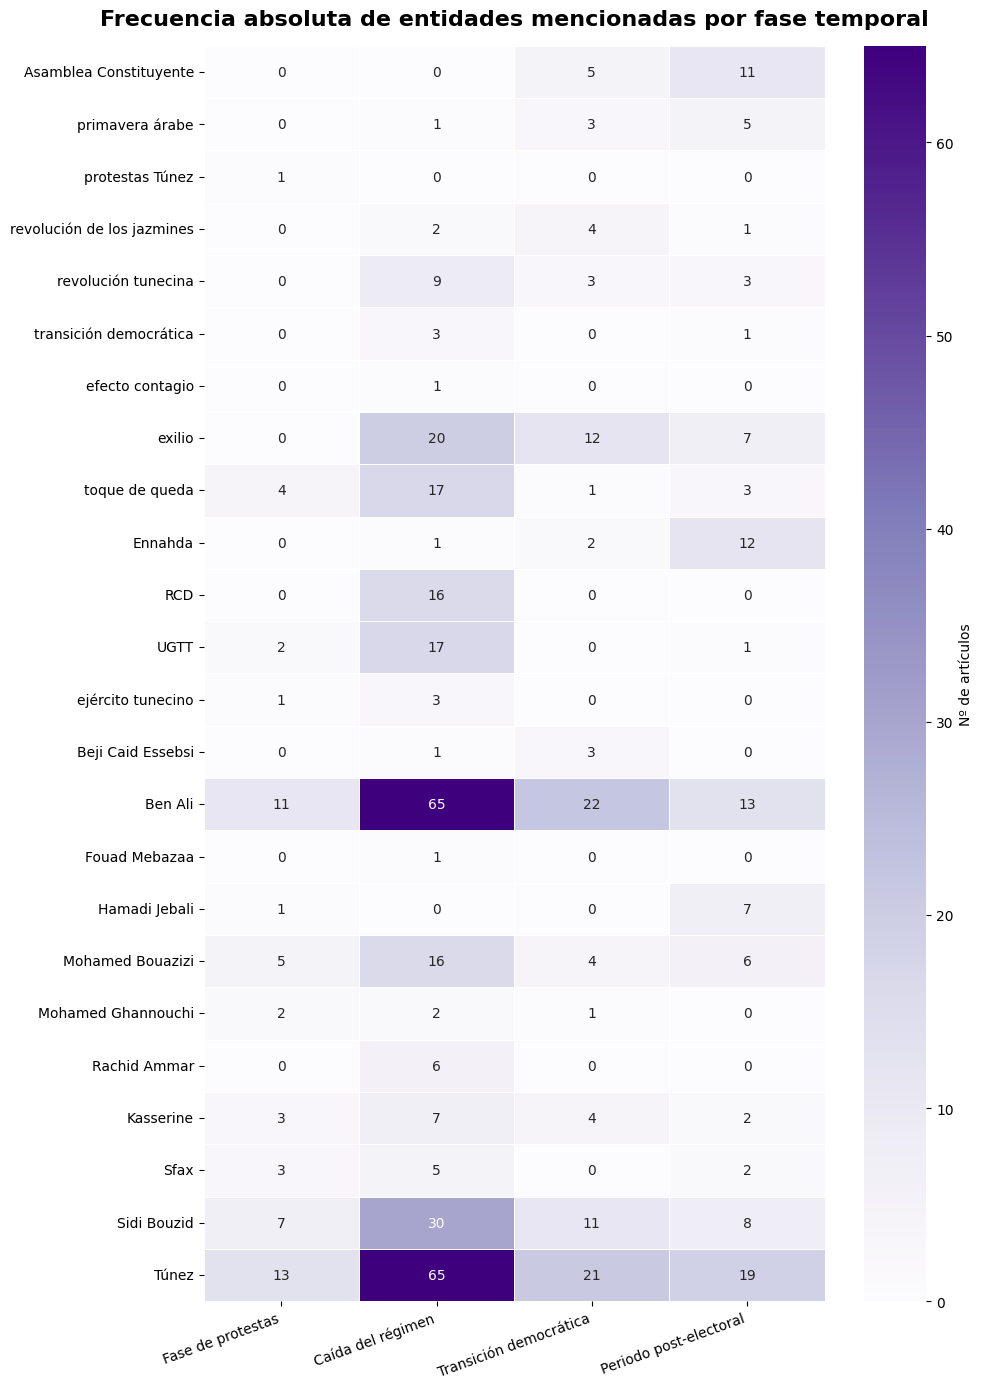

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(tabla_entidad_fase.T, annot=True, fmt='d', cmap="Purples",
            cbar_kws={'label': 'Nº de artículos'}, linewidths=0.5, linecolor='white')

ax.set_title("Frecuencia absoluta de entidades mencionadas por fase temporal", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

2. GRÁFICO ENTIDADES MENCIONADAS POR FASE TEMPORAL II (prevalencia relativa)

- ¿Qué entidades dominan proporcionalmente en cada fase?

Artículos por fase:
periodo_fase
Caída del régimen         68
Transición democrática    24
Periodo post-electoral    21
Fase de protestas         13
Name: count, dtype: int64

Porcentaje de artículos de cada fase que mencionan cada entidad:
periodo_fase                Fase de protestas  Caída del régimen  \
entidades_detectadas                                               
Asamblea Constituyente                    0.0                0.0   
primavera árabe                           0.0                1.5   
protestas Túnez                           7.7                0.0   
revolución de los jazmines                0.0                2.9   
revolución tunecina                       0.0               13.2   
transición democrática                    0.0                4.4   
efecto contagio                           0.0                1.5   
exilio                                    0.0               29.4   
toque de queda                           30.8               25.0   
Ennahda    

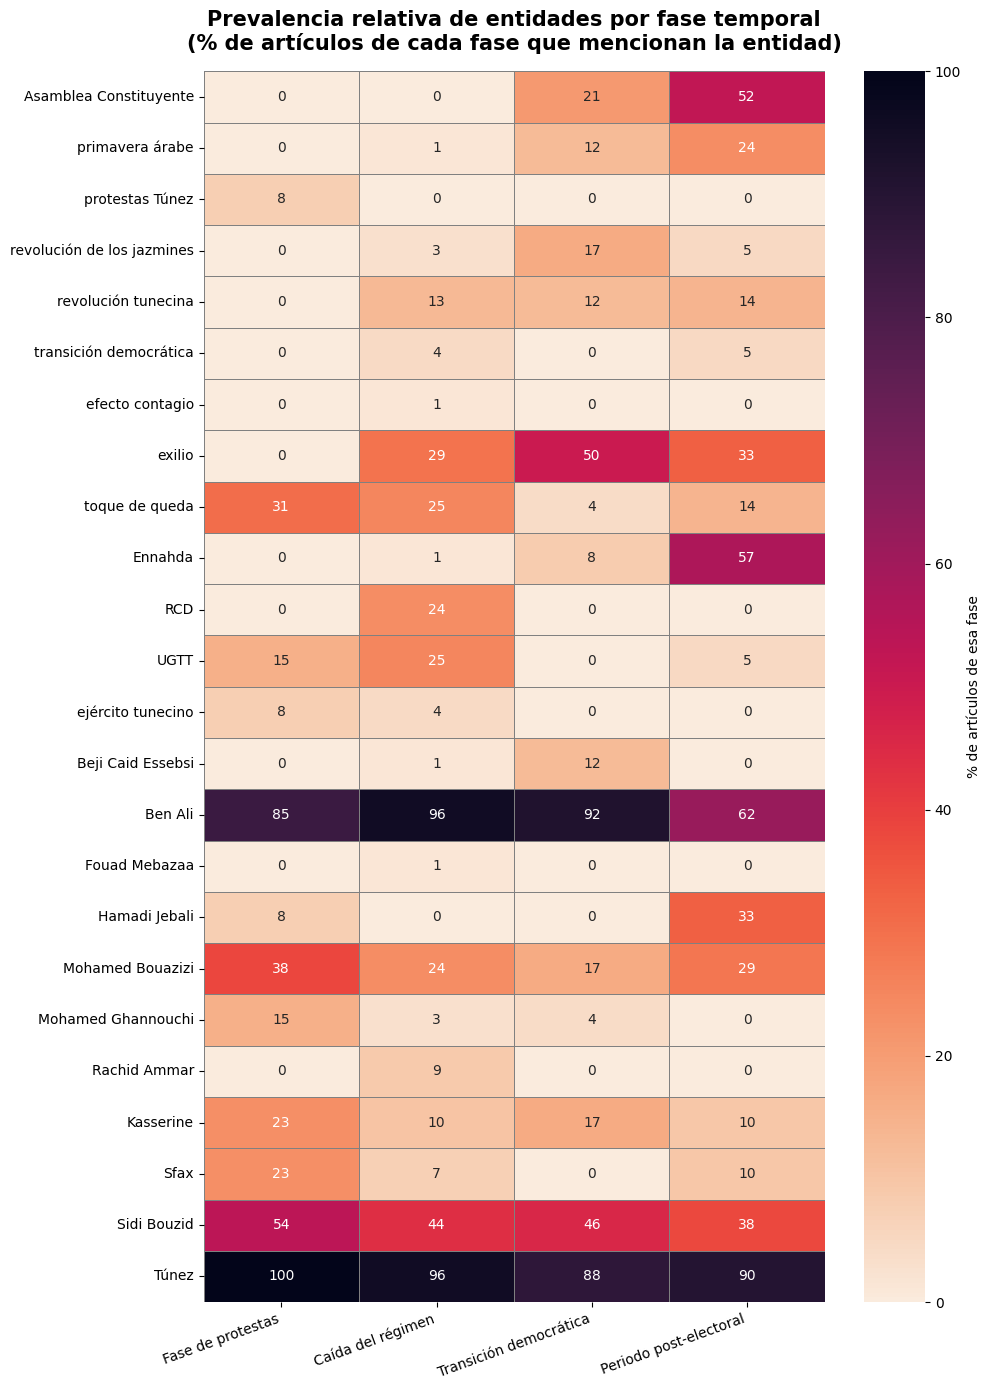

In [16]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Paso 0: recuperar el mapeo término -> grupo desde el YAML ---
with open("tunez.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

termino_a_grupo = {}
for grupo in ["place", "people", "organizations", "concepts", "narrative_markers"]:
    for item in config.get(grupo, []):
        termino_a_grupo[item["term"]] = grupo

# --- Paso 1: contar artículos por fase (sobre df_analisis, el original) ---
articulos_por_fase = df_analisis['periodo_fase'].value_counts()
print("Artículos por fase:")
print(articulos_por_fase)

# --- Paso 2: expandir el corpus (una fila por cada entidad mencionada) ---
df_expandido = df_analisis.explode('entidades_detectadas')
df_expandido['grupo_entidad'] = df_expandido['entidades_detectadas'].map(termino_a_grupo)

# --- Paso 3: tabla de menciones absolutas (fase x entidad) ---
tabla_entidad_fase = pd.crosstab(df_expandido['periodo_fase'], df_expandido['entidades_detectadas'])

# --- Paso 4: normalizar por nº de artículos de cada fase -> porcentaje ---
tabla_entidad_fase_pct = tabla_entidad_fase.div(articulos_por_fase, axis=0) * 100

# --- Paso 5: ordenar filas por fase y columnas por grupo del YAML ---
orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]
tabla_entidad_fase_pct = tabla_entidad_fase_pct.reindex(orden_fases)

columnas_ordenadas = sorted(tabla_entidad_fase_pct.columns, key=lambda c: termino_a_grupo.get(c, ''))
tabla_entidad_fase_pct = tabla_entidad_fase_pct[columnas_ordenadas]

print("\nPorcentaje de artículos de cada fase que mencionan cada entidad:")
print(tabla_entidad_fase_pct.T.round(1))

# --- Paso 6: heatmap ---
fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(tabla_entidad_fase_pct.T, annot=True, fmt='.0f', cmap="rocket_r",
            cbar_kws={'label': '% de artículos de esa fase'}, linewidths=0.5, linecolor='grey')

ax.set_title("Prevalencia relativa de entidades por fase temporal\n(% de artículos de cada fase que mencionan la entidad)",
              fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

3. CATEGORÍA QUE MÁS PREDOMINA SEGÚN LA FASE

In [17]:
#Calcular, por artículo, si menciona al menos una entidad de cada categoría
grupos = ["place", "people", "organizations", "concepts", "narrative_markers"]

for grupo in grupos:
    df_analisis[f'tiene_{grupo}'] = df_analisis['entidades_detectadas'].apply(lambda lista: any(termino_a_grupo.get(e) == grupo for e in lista))

In [18]:
#Calcular el % de artículos de cada fase que mencionan cada categoría
orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]

tabla_categoria_fase = df_analisis.groupby('periodo_fase')[[f'tiene_{g}' for g in grupos]].mean() * 100
tabla_categoria_fase.columns = grupos
tabla_categoria_fase = tabla_categoria_fase.reindex(orden_fases)
print(tabla_categoria_fase.round(1))

                        place  people  organizations  concepts  \
periodo_fase                                                     
Fase de protestas       100.0   100.0           23.1       7.7   
Caída del régimen        98.5    95.6           39.7      19.1   
Transición democrática   87.5    95.8            8.3      58.3   
Periodo post-electoral   95.2    85.7           57.1      76.2   

                        narrative_markers  
periodo_fase                               
Fase de protestas                    30.8  
Caída del régimen                    50.0  
Transición democrática               54.2  
Periodo post-electoral               47.6  


In [19]:
#Pasar a formato "largo" para Plotly, y añadir qué entidades concretas hay detrás (para el hover)
tabla_larga = tabla_categoria_fase.reset_index().melt(id_vars='periodo_fase', var_name='categoria', value_name='porcentaje')

def entidades_de_categoria_en_fase(fase, categoria):
    subset = df_analisis[df_analisis['periodo_fase'] == fase]
    entidades = set()
    for lista in subset['entidades_detectadas']:
        for e in lista:
            if termino_a_grupo.get(e) == categoria:
                entidades.add(e)
    return ", ".join(sorted(entidades)) if entidades else "(ninguna)"

tabla_larga['entidades_detalle'] = tabla_larga.apply(lambda row: entidades_de_categoria_en_fase(row['periodo_fase'], row['categoria']), axis=1)

In [20]:
#Calcular el término más repetido de cada categoría, por fase
def termino_top(fase, categoria_en):
    subset = df_expandido[(df_expandido['periodo_fase'] == fase) & (df_expandido['grupo_entidad'] == categoria_en)]
    if len(subset) == 0:
        return ""
    return subset['entidades_detectadas'].value_counts().idxmax()

tabla_larga['termino_top'] = tabla_larga.apply(lambda row: termino_top(row['periodo_fase'], row['categoria']), axis=1)

In [21]:
# traducir las categorías y añadirlas al df_tabla_larga
traduccion_categoria = {
    "place": "Lugares", "people": "Personas", "organizations": "Organizaciones",
    "concepts": "Conceptos", "narrative_markers": "Marcadores narrativos"}

tabla_larga['categoria_es'] = tabla_larga['categoria'].map(traduccion_categoria)
orden_categorias_es = ["Lugares", "Personas", "Organizaciones", "Conceptos", "Marcadores narrativos"]

In [22]:
import plotly.express as px

# Fechas de cada fase (mismo diccionario que ya usamos en el resto del notebook)
FASES_FECHAS = {
    "Fase de protestas": "17/12/2010 – 13/01/2011",
    "Caída del régimen": "14/01/2011 – 28/02/2011",
    "Transición democrática": "01/03/2011 – 22/10/2011",
    "Periodo post-electoral": "23/10/2011 – 31/12/2011",
}

fig = px.scatter(
    tabla_larga,
    x='categoria_es',
    y='porcentaje',
    color='categoria_es',
    size='porcentaje',
    size_max=55,
    text='termino_top',
    facet_col='periodo_fase',
    category_orders={'periodo_fase': orden_fases, 'categoria_es': orden_categorias_es},
    hover_data={'entidades_detalle': True, 'porcentaje': ':.1f', 'categoria_es': False, 'periodo_fase': False, 'termino_top': False},
    color_discrete_map={
        "Lugares": "#2A9D8F",
        "Personas": "#6A4C93",
        "Organizaciones": "#1D3557",
        "Conceptos": "#E9C46A",
        "Marcadores narrativos": "#F4A261"},
    title="Prevalencia relativa de cada categoría de entidad por fase temporal")

fig.update_traces(textposition='middle center', textfont=dict(size=8, color='black'))
fig.update_xaxes(showticklabels=False)
fig.update_layout(yaxis_title="% de artículos de esa fase", legend_title="Categoría", height=650)

# Título de cada panel: nombre de la fase + fecha debajo (en vez de solo "periodo_fase=...")
fig.for_each_annotation(
    lambda a: a.update(
        text=f"<b>{a.text.split('=')[-1]}</b><br><span style='font-size:11px;color:#6B6B6B'>{FASES_FECHAS[a.text.split('=')[-1]]}</span>"
    )
)

fig.update_xaxes(title_text="")
fig.show()

4. ENTIDADES SEGÚN LA CATEGORÍA CON PREVALENCIA RELATIVA%

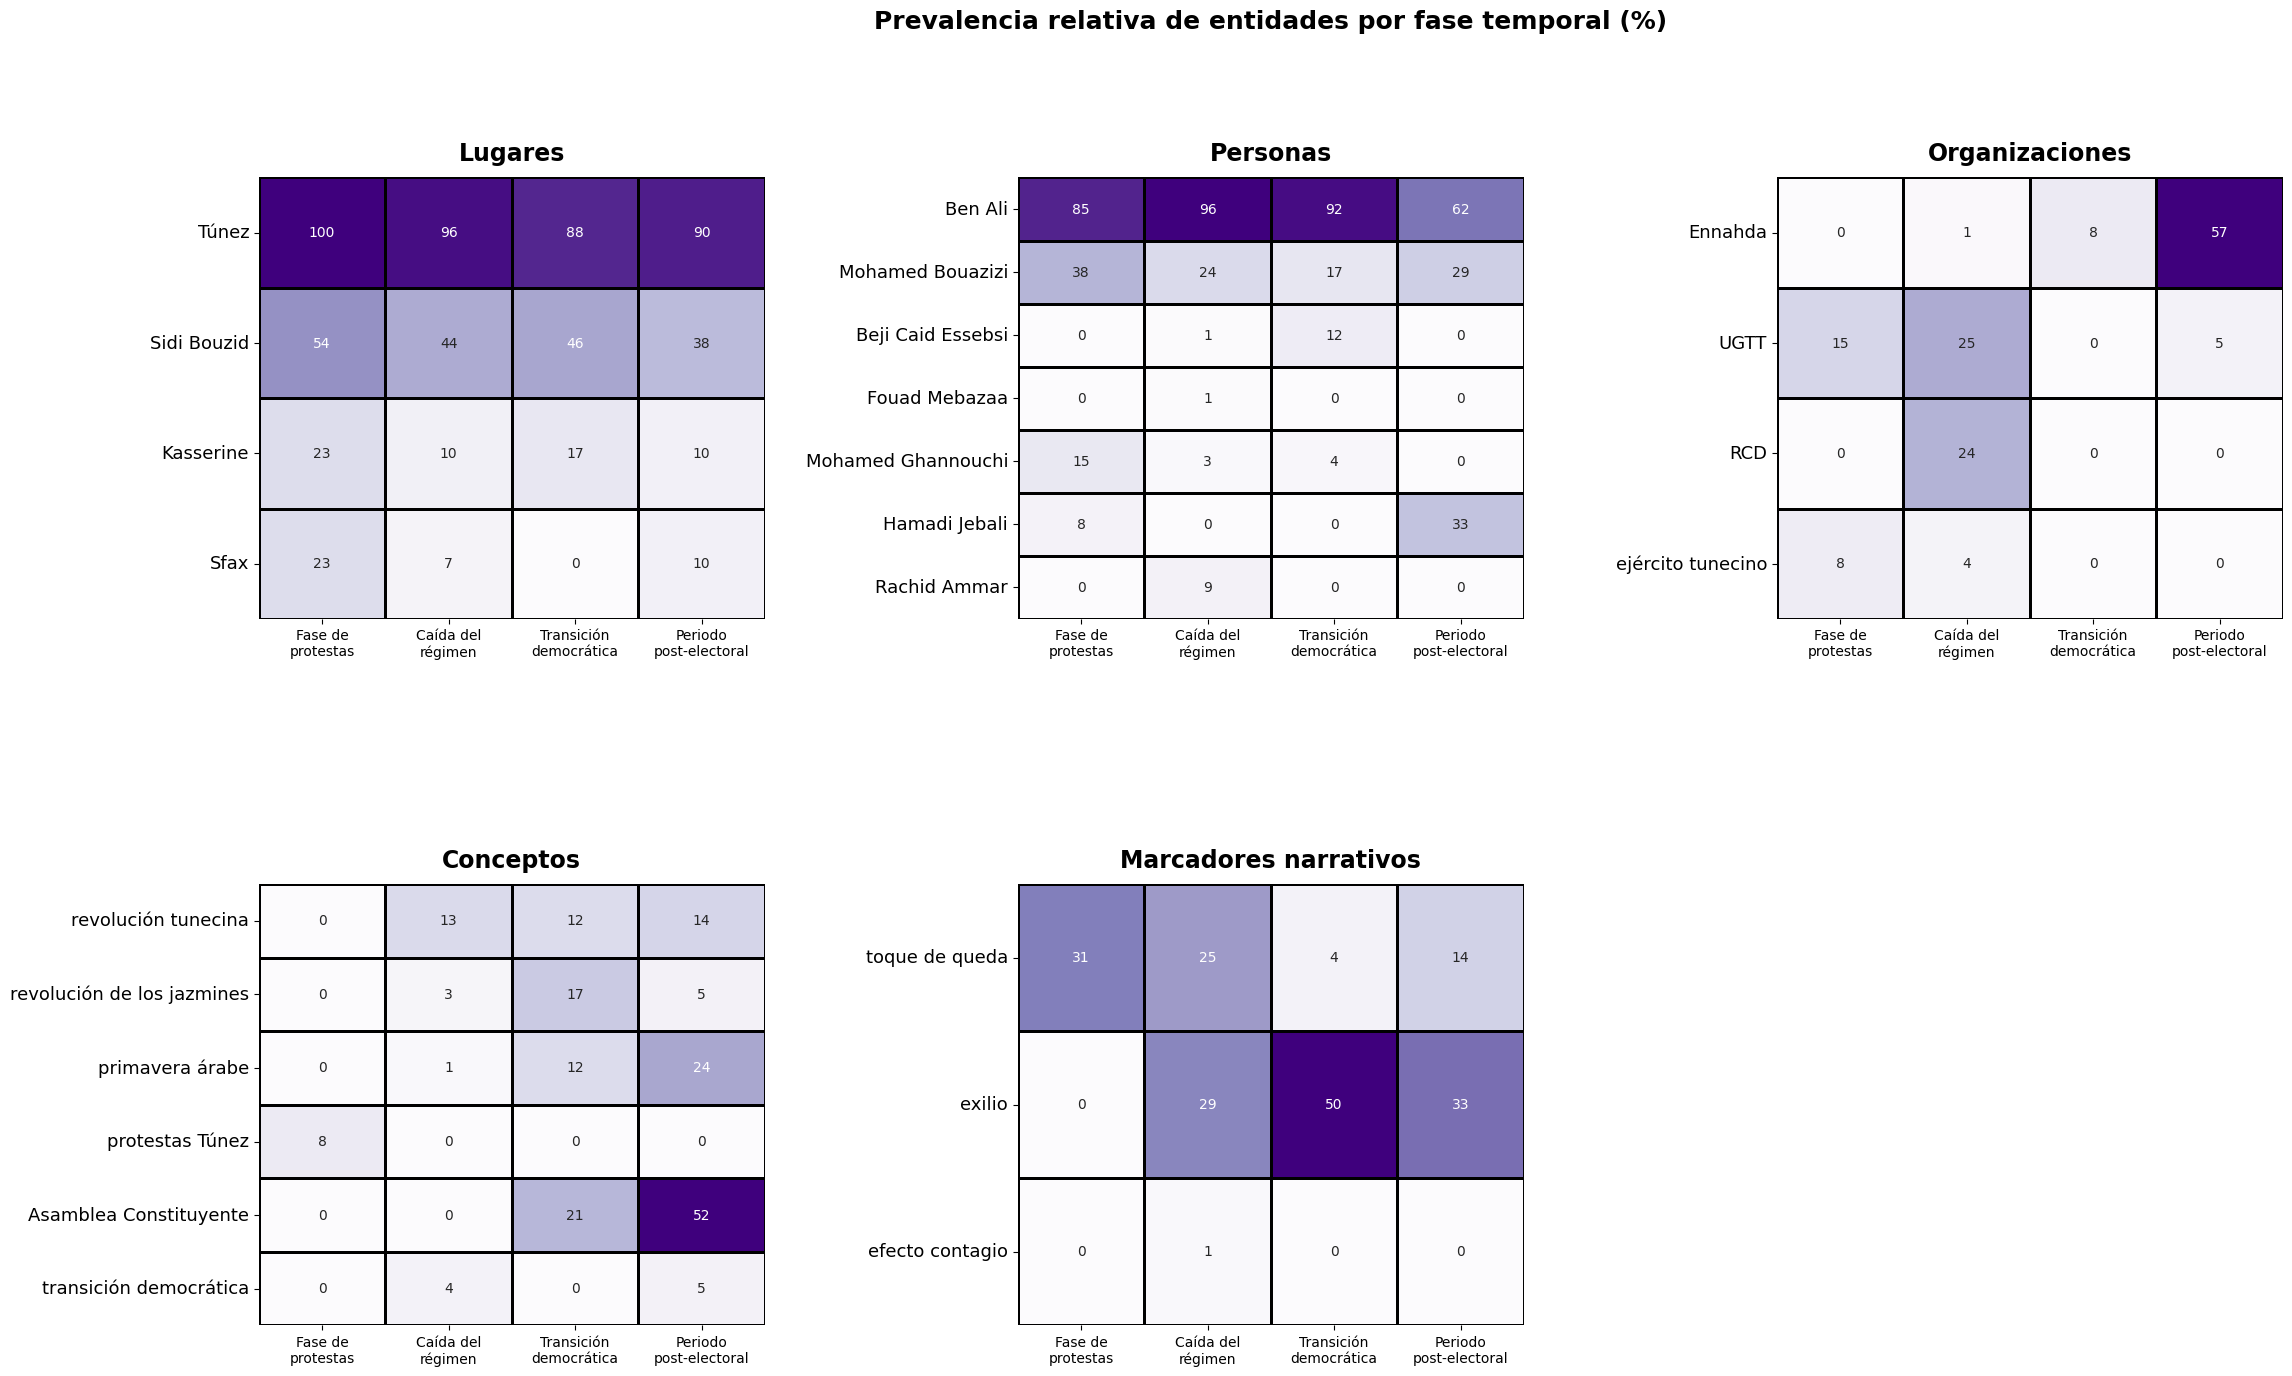

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]
grupos = ["place", "people", "organizations", "concepts", "narrative_markers"]
traduccion_categoria = {"place": "Lugares", "people": "Personas", "organizations": "Organizaciones",
                         "concepts": "Conceptos", "narrative_markers": "Marcadores narrativos"}

etiquetas_fase_partidas = {
    "Fase de protestas": "Fase de\nprotestas",
    "Caída del régimen": "Caída del\nrégimen",
    "Transición democrática": "Transición\ndemocrática",
    "Periodo post-electoral": "Periodo\npost-electoral",
}

fig, axes = plt.subplots(2, 3, figsize=(22, 14)) 
axes_flat = axes.flatten()

for ax, grupo in zip(axes_flat, grupos):
    entidades_grupo = [e for e, g in termino_a_grupo.items() if g == grupo]
    tabla_grupo = tabla_entidad_fase_pct[[e for e in entidades_grupo if e in tabla_entidad_fase_pct.columns]]
    sns.heatmap(tabla_grupo.T, annot=True, fmt='.0f', cmap="Purples", cbar=False,
                linewidths=1, linecolor='black', ax=ax)
    ax.set_title(traduccion_categoria[grupo], fontsize=17, fontweight='bold', pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=13)

    etiquetas_actuales = [t.get_text() for t in ax.get_xticklabels()]
    nuevas_etiquetas = [etiquetas_fase_partidas.get(e, e) for e in etiquetas_actuales]
    ax.set_xticklabels(nuevas_etiquetas, rotation=0, ha='center', fontsize=10)

axes_flat[5].axis('off')

fig.suptitle("Prevalencia relativa de entidades por fase temporal (%)", fontsize=18, fontweight='bold', y=1.02)

# Espaciado entre subgráficos (en vez de tight_layout)
plt.subplots_adjust(hspace=0.6, wspace=0.5, left=0.04, right=0.96, top=0.90, bottom=0.08)
plt.show()

In [24]:
df_analisis.head(2)

,id_articulo,fecha,hora,zona_horaria,titulo,autor,subtitulo,url,palabra_clave,cuerpo_noticia,longitud_cuerpo,entidades_detectadas,n_entidades,periodo_fase,texto_análisis,tiene_place,tiene_people,tiene_organizations,tiene_concepts,tiene_narrative_markers
0,1,2011-01-23,07:02:00,CET,La llama que incendió Túnez,Juan Miguel Muñoz,La inmolación del vendedor de frutas Mohamed B...,https://elpais.com/diario/2011/01/23/domingo/1...,Mohamed Bouazizi,La llama que incendió Túnez La inmolación del ...,21592,"[Ben Ali, Mohamed Bouazizi, RCD, Rachid Ammar,...",8,Caída del régimen,La llama que incendió Túnez La inmolación del ...,True,True,True,False,True
1,2,2011-01-17,15:23:00,CET,Un egipcio y un mauritano se queman a lo bonzo,NaN,Se suman un argelino y a otros dos tunecinos q...,https://elpais.com/internacional/2011/01/17/ac...,Mohamed Bouazizi,Un egipcio y un mauritano se queman a lo bonzo...,5781,"[Ben Ali, Mohamed Bouazizi, Túnez]",3,Caída del régimen,Un egipcio y un mauritano se queman a lo bonzo...,True,True,False,False,False


## 6. ANÁLISIS DE SENTIMIENTO

1. Análisis cualitativo del corpus y su contenido

In [25]:
df_analisis["texto_análisis"].sample(5)

13    Los islamistas dominan el primer Gobierno demo...
80    Túnez sienta en el banquillo a la dictadura de...
48    Los dos principales asesores de Ben Ali, bajo ...
60    Túnez echa a los últimos ministros de Ben Ali ...
7     La ‘primavera árabe’: una visión personal La a...
Name: texto_análisis, dtype: object

In [26]:
df_analisis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id_articulo              126 non-null    int64         
 1   fecha                    126 non-null    datetime64[ns]
 2   hora                     126 non-null    object        
 3   zona_horaria             126 non-null    object        
 4   titulo                   126 non-null    object        
 5   autor                    75 non-null     object        
 6   subtitulo                101 non-null    object        
 7   url                      126 non-null    object        
 8   palabra_clave            126 non-null    object        
 9   cuerpo_noticia           126 non-null    object        
 10  longitud_cuerpo          126 non-null    int64         
 11  entidades_detectadas     126 non-null    object        
 12  n_entidades              126 non-nul

In [27]:
df_expandido["texto_análisis"].isna().sum()

np.int64(0)

In [28]:
df_expandido["texto_análisis"].sample(5)

71    El policía que llegó a caudillo Ben Ali hizo c...
86    Túnez reclama a Arabia Saudí la extradición de...
2     El joven mártir que cambió el destino de un pa...
50    La policía tunecina carga con gases lacrimógen...
60    Túnez echa a los últimos ministros de Ben Ali ...
Name: texto_análisis, dtype: object

1. ### INSTALAR LIBRERIAS DE ANÁLISIS DE SENTIMIENTO

In [29]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from pysentimiento import create_analyzer

Creación del analizador de sentimiento en español

In [30]:
analyzer = create_analyzer(task="sentiment",lang="es")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Prueba del analizador

In [31]:
resultado = analyzer.predict("La situación política en Túnez empeora cada día.")

print(resultado.output)
print(resultado.probas)

NEG
{'NEG': 0.9266020655632019, 'NEU': 0.0660354346036911, 'POS': 0.007362601812928915}


#### 2. FUNCIÓN PARA ANALIZAR EL SENTIMIENTO EN EL TEXTO:

In [32]:
def analizar_sentimiento(texto):

    if pd.isna(texto) or texto == "":
        return pd.Series([None, None, None, None, None])

    resultado = analyzer.predict(texto)

    # Si devuelve una lista, cogemos el primer elemento
    if isinstance(resultado, list):
        resultado = resultado[0]

    return pd.Series([
        str(resultado.output),
        resultado.probas["NEG"],
        resultado.probas["NEU"],
        resultado.probas["POS"],
        max(resultado.probas.values())])

APLICACIÓN:

Se aplica el análisis de sentimiento en el df_analisis que respresenta cada fila 1 artículo

In [33]:
#SENTIMIENTO PARA EL TÍTULO
df_analisis[["sentimiento", "prob_neg", "prob_neu", "prob_pos", "confianza"]] = (df_analisis["titulo"].apply(analizar_sentimiento))

DIVISIÓN DEL EL TEXTO DEL CUERPO PARA QUE PUEDA ANALIZARSE 

In [34]:
# Función para dividir el texto en fragmentos de 400 palabras. Esta longitud se utiliza como aproximación para no superar el límite de entrada del modelo Transformer.
def dividir_en_fragmentos(texto, palabras_por_fragmento=400):
    palabras = str(texto).split()

    fragmentos = [" ".join(palabras[i:i + palabras_por_fragmento])
        for i in range(0, len(palabras), palabras_por_fragmento)]
    return fragmentos

In [35]:
# FUNCIÓN PARA ANALIZAR EL SENTIMIENTO DE UN TEXTO LARGO (CUERPO DE LA NOTICIA)
def analizar_sentimiento_largo(texto):
    if pd.isna(texto) or texto == "":
        return pd.Series([None, None, None, None, None])

    fragmentos = dividir_en_fragmentos(texto)
    resultados = [analyzer.predict(frag) for frag in fragmentos]
    resultados = [r[0] if isinstance(r, list) else r for r in resultados]

    neg = sum(r.probas["NEG"] for r in resultados) / len(resultados)
    neu = sum(r.probas["NEU"] for r in resultados) / len(resultados)
    pos = sum(r.probas["POS"] for r in resultados) / len(resultados)

    probas_medias = {"NEG": neg, "NEU": neu, "POS": pos}
    sentimiento_final = max(probas_medias, key=probas_medias.get)
    confianza_final = max(probas_medias.values())

    return pd.Series([sentimiento_final, neg, neu, pos, confianza_final])

In [36]:
#SENTIMIENTO PARA EL CUERPO DE LA NOTICIA
df_analisis[["sentimiento_cuerpo", "prob_neg_cuerpo", "prob_neu_cuerpo", "prob_pos_cuerpo", "confianza_cuerpo"]] = (
    df_analisis["cuerpo_noticia"].apply(analizar_sentimiento_largo))

In [37]:
df_analisis.head(2)

,id_articulo,fecha,hora,zona_horaria,titulo,autor,subtitulo,url,palabra_clave,cuerpo_noticia,...,sentimiento,prob_neg,prob_neu,prob_pos,confianza,sentimiento_cuerpo,prob_neg_cuerpo,prob_neu_cuerpo,prob_pos_cuerpo,confianza_cuerpo
0,1,2011-01-23,07:02:00,CET,La llama que incendió Túnez,Juan Miguel Muñoz,La inmolación del vendedor de frutas Mohamed B...,https://elpais.com/diario/2011/01/23/domingo/1...,Mohamed Bouazizi,La llama que incendió Túnez La inmolación del ...,...,NEU,0.301286,0.556904,0.141810,0.556904,NEG,0.700106,0.266168,0.033726,0.700106
1,2,2011-01-17,15:23:00,CET,Un egipcio y un mauritano se queman a lo bonzo,NaN,Se suman un argelino y a otros dos tunecinos q...,https://elpais.com/internacional/2011/01/17/ac...,Mohamed Bouazizi,Un egipcio y un mauritano se queman a lo bonzo...,...,NEU,0.267402,0.627397,0.105201,0.627397,NEG,0.870454,0.114600,0.014946,0.870454


ANÁLISIS DE LA CONFIANZA DEL MODELO EN EL TÍTULO

<Axes: >

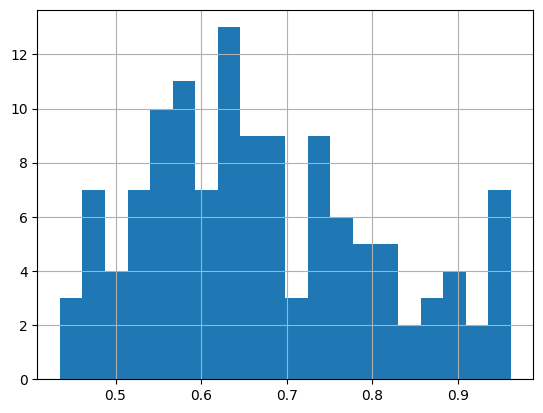

In [38]:
#TÍTULO
df_analisis["confianza"].hist(bins=20)

<Axes: >

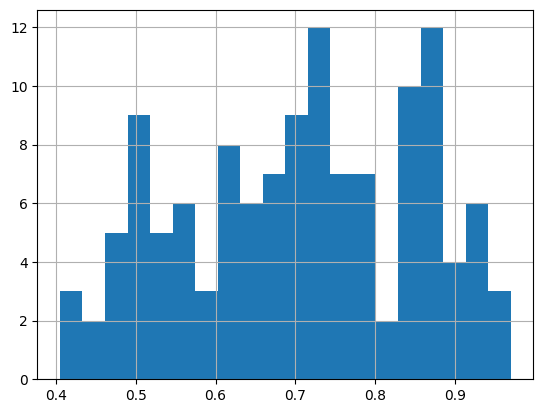

In [39]:
#CUERPO
df_analisis["confianza_cuerpo"].hist(bins=20)

In [40]:
df_analisis["confianza"].mean()

np.float64(0.6710425322017972)

In [41]:
df_analisis["confianza_cuerpo"].mean()

np.float64(0.7044408860246814)

La confianza media de las predicciones fue de 0,67, lo que indica un nivel moderado de seguridad en la clasificación. Este resultado es coherente con la naturaleza de los titulares periodísticos, que suelen emplear un lenguaje predominantemente informativo y menos explícitamente valorativo que otros tipos de textos.

TITULAR (TÍTULO) 

In [42]:
# TÍTULO Determinar la media, mínimo, máximo y número de artículos por sentimiento para ver el porcentaje de confianza en la predicción de sentimiento
df_analisis.groupby("sentimiento")["confianza"].agg(["mean", "min", "max", "count"])

,mean,min,max,count
sentimiento,,,,
NEG,0.752280,0.435000,0.961524,50
NEU,0.613469,0.461086,0.805922,68
POS,0.652682,0.476451,0.875773,8


CUERPO DE LA NOTICIA

In [43]:
#CUERPO DE LA NOTICIA Determinar la media, mínimo, máximo y número de artículos por sentimiento para ver el porcentaje de confianza en la predicción de sentimiento en el cuerpo

df_analisis.groupby("sentimiento_cuerpo")["confianza_cuerpo"].agg(["mean", "min", "max", "count"])

,mean,min,max,count
sentimiento_cuerpo,,,,
NEG,0.737740,0.435259,0.969442,102
NEU,0.563103,0.405306,0.769517,22
POS,0.560926,0.516505,0.605347,2


TÍTULAR (TÍTULO) -Frecuencia de cada categoría presente en la columna sentimiento.

In [44]:
df_analisis["sentimiento"].value_counts()

sentimiento
NEU    68
NEG    50
POS     8
Name: count, dtype: int64

CUERPO DE LA NOTICIA -  Frecuencia de cada categoría presente en la columna sentimiento.

In [45]:
df_analisis["sentimiento_cuerpo"].value_counts()

sentimiento_cuerpo
NEG    102
NEU     22
POS      2
Name: count, dtype: int64

TABLA CONTINGENCIA SENTIMIENTO TÍTULO VS CUERPO

Tabla de contingencia que muestra el porcentaje de artículos de cada sentimiento dentro de cada fase temporal. En lugar de contar artículos, convierte cada fila en porcentajes. Para poder comparar fases aunque tengan el mismo número de artículos

1. Tabla contingencia título

In [46]:
#TÍTULO: Tabla de contingencia para ver el porcentaje de artículos de cada fase que tienen sentimiento positivo, negativo o neutro en el título
tabla_titulo = pd.crosstab(df_analisis["periodo_fase"],df_analisis["sentimiento"],normalize="index") * 100
tabla_titulo.round(1)

sentimiento,NEG,NEU,POS
periodo_fase,,,
Caída del régimen,39.7,51.5,8.8
Fase de protestas,76.9,23.1,0.0
Periodo post-electoral,23.8,71.4,4.8
Transición democrática,33.3,62.5,4.2


2. Tabla contingencia cuerpo

In [47]:
#CUERPO DE LA NOTICIA: Tabla de contingencia para ver el porcentaje de artículos de cada fase que tienen sentimiento positivo, negativo o neutro en el cuerpo
tabla_cuerpo = pd.crosstab(df_analisis["periodo_fase"],df_analisis["sentimiento_cuerpo"],normalize="index") * 100
tabla_cuerpo.round(1)

sentimiento_cuerpo,NEG,NEU,POS
periodo_fase,,,
Caída del régimen,88.2,11.8,0.0
Fase de protestas,84.6,15.4,0.0
Periodo post-electoral,66.7,23.8,9.5
Transición democrática,70.8,29.2,0.0


EXTRACCIÓN MODULAR DE PALABRAS FRECUENTES: en titular/cuerpo y tipo de sentimiento 

In [48]:
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

stop = set(stopwords.words("spanish"))
extra = {

    # País y gentilicios
    "túnez", "tunecino", "tunecina", "tunecinos", "tunecinas", "egipto", "ciudad","ciudades","mundo",

    # Nombres propios muy frecuentes
    "ben", "ali", "bouazizi","gadafi",

    # Verbos periodísticos
    "dice", "dijo", "dicen","afirma", "afirma", "afirmó","asegura", "aseguró","anuncia", "anunció","explica", "explicó","considera","señala",
    "pide", "pidió",

    # Conectores muy frecuentes
    "tras","ante","según","entre","desde","hasta",
    "sobre","contra", "ser","haber","hacer","tener",
    "ir","dar","llegar","puede","podría","debe",
    "deber","aún","ya","dos","tres","cinco","mucha","gracias","allí",

    # Términos genéricos de prensa
    "hoy","ayer","nuevo", "nueva", "nuevos", "nuevas","años",
    "último", "última","primer", "primera","tercera","tercer","vez", "forma", "parte", "caso", "persona", "personas",

    # Cantidad
    "miles", "cientos", "millones",

    # Agencias
    "efe", "reuters", "afp"}

stop.update(extra)
texto = " ".join(df_analisis[df_analisis["sentimiento"]=="NEU"]["cuerpo_noticia"]).lower() #Cambiar "titulo" por "cuerpo_noticia" para analizar el cuerpo de la noticia
texto = re.sub(r"[^\w\s]", "", texto)                                                       #Cambiar para ver el tipo de sentimiento.
tokens = word_tokenize(texto)
tokens = [t for t in tokens
    if t not in stop and len(t) > 2]

Counter(tokens).most_common(20)

[('país', 202),
 ('presidente', 150),
 ('gobierno', 138),
 ('árabe', 113),
 ('poder', 112),
 ('revolución', 101),
 ('régimen', 90),
 ('ministro', 86),
 ('ahora', 76),
 ('policía', 72),
 ('mohamed', 71),
 ('enero', 71),
 ('sido', 70),
 ('después', 69),
 ('protestas', 66),
 ('solo', 63),
 ('capital', 63),
 ('partido', 63),
 ('democracia', 63),
 ('árabes', 62)]

## DETECCIÓN DE BIGRAMAS

EXPLORACIÓN PRELIMINAR: bigramas por sentimiento, solo sobre el titular y sin distinguir por fase.
Para validar el enfoque antes de construir la versión completa (cruzada por fase + sentimiento,
título y cuerpo) que se usa más abajo para las nubes de palabras. Se conserva como referencia.

In [49]:
from collections import Counter
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import re

def obtener_bigramas(df, sentimiento, columna="titulo", top=20):
    texto = " ".join(df[df["sentimiento"] == sentimiento][columna].dropna()).lower()

    texto = re.sub(r"[^a-záéíóúüñ\s]", "", texto)
    tokens = word_tokenize(texto)
    tokens = [t for t in tokens
               if t not in stop and len(t) > 2]

    bigramas = Counter(" ".join(bg) for bg in ngrams(tokens, 2))

    return bigramas.most_common(top)

In [50]:
#prueba de validación
obtener_bigramas(df_analisis, "NEG")

[('revuelta popular', 2),
 ('onu revolución', 1),
 ('revolución costó', 1),
 ('costó muertos', 1),
 ('muertos transición', 1),
 ('transición investigar', 1),
 ('investigar crímenes', 1),
 ('crímenes alí', 1),
 ('alí dictador', 1),
 ('dictador huye', 1),
 ('huye acosado', 1),
 ('acosado revuelta', 1),
 ('popular muerto', 1),
 ('muerto bonzo', 1),
 ('bonzo robado', 1),
 ('robado revolución', 1),
 ('revolución muerte', 1),
 ('muerte recrudecimiento', 1),
 ('recrudecimiento protestas', 1),
 ('protestas exteriores', 1)]

## Análisis de frecuencia de palabras y bigramas


Se agrupan los titulares según la categoría de sentimiento asignada por el modelo (`NEG`, `NEU` y `POS`). 
El texto se preprocesa convirtiéndolo a minúsculas, eliminando signos de puntuación, números, palabras vacías (*stopwords*) del español y un diccionario adicional de términos frecuentes del corpus (nombres propios, gentilicios y expresiones periodísticas) que no aportaban información relevante al análisis.

El texto se tokeniza para obtener las palabras individuales (*unigramas*) y se calculó su frecuencia mediante la clase `Counter` de la biblioteca `collections`.

Se extraen **bigramas**,secuencias de dos palabras consecutivas, utilizando la función `ngrams()` de NLTK para identificar expresiones compuestas con significado propio.

#### GRÁFICO: comparación de sentimiento entre titular y cuerpo según las diferentes fases

¿Hay divergencia de sentimiento entre titular y cuerpo?

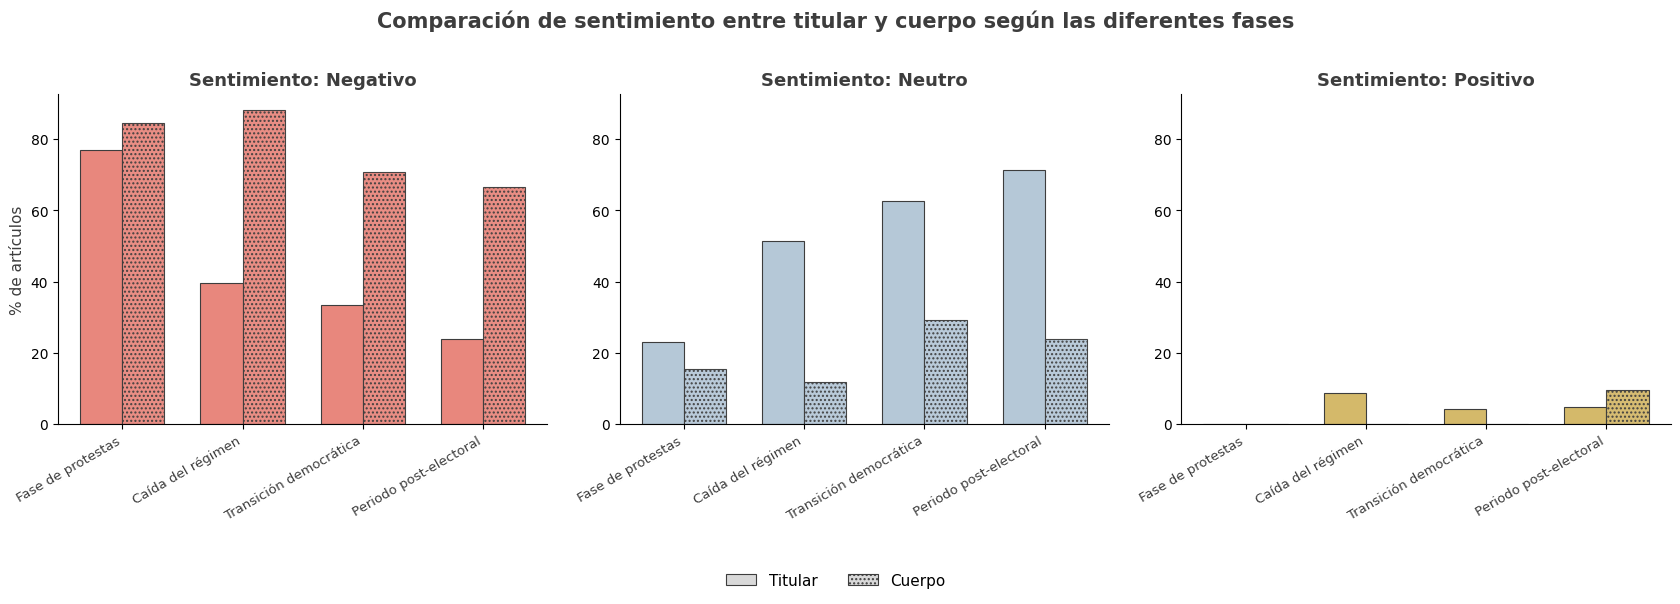

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---- Paleta del proyecto, aplicada por sentimiento ----
COLOR_NEG = "#E8877D"   # coral
COLOR_NEU = "#B5C8D7"   # azul claro (tinte del azul acero)
COLOR_POS = "#D4B96A"   # ocre
COLOR_TEXTO = "#3D3D3D"
COLOR_GRIS = "#6B6B6B"

colores_sentimiento = {"NEG": COLOR_NEG, "NEU": COLOR_NEU, "POS": COLOR_POS}

orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]
tabla_titulo = tabla_titulo.reindex(orden_fases)
tabla_cuerpo = tabla_cuerpo.reindex(orden_fases)

traduccion_sentimiento = {"NEG": "Negativo", "NEU": "Neutro", "POS": "Positivo"}
sentimientos = ["NEG", "NEU", "POS"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
x = np.arange(len(orden_fases))
ancho = 0.35

for ax, sent in zip(axes, sentimientos):
    color = colores_sentimiento[sent]

    # Titular: color liso
    ax.bar(x - ancho/2, tabla_titulo[sent], width=ancho, color=color,
           edgecolor=COLOR_TEXTO, linewidth=0.8)

    # Cuerpo: mismo color, con granulado fino encima
    ax.bar(x + ancho/2, tabla_cuerpo[sent], width=ancho, color=color,
           edgecolor=COLOR_TEXTO, linewidth=0.8, hatch='....', alpha=0.95)

    ax.set_title(f"Sentimiento: {traduccion_sentimiento[sent]}", fontweight='bold',
                 fontsize=13, color=COLOR_TEXTO)
    ax.set_xticks(x)
    ax.set_xticklabels(orden_fases, rotation=30, ha='right', fontsize=9.5, color=COLOR_TEXTO)
    ax.tick_params(labelleft=True)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel("% de artículos", fontsize=11, color=COLOR_TEXTO)

# Leyenda: solo distingue Titular vs Cuerpo (el color ya lo explica el título de cada panel)
leyenda = [
    mpatches.Patch(facecolor="#D9D9D9", edgecolor=COLOR_TEXTO, linewidth=0.8, label="Titular"),
    mpatches.Patch(facecolor="#D9D9D9", edgecolor=COLOR_TEXTO, linewidth=0.8, hatch='....', label="Cuerpo"),
]
fig.legend(handles=leyenda, loc='upper center', bbox_to_anchor=(0.5, 0.02),
           ncol=2, fontsize=11, frameon=False)

fig.suptitle("Comparación de sentimiento entre titular y cuerpo según las diferentes fases",
             fontsize=15, fontweight='bold', color=COLOR_TEXTO, y=1.02)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### WORDCLOUD: Construcción de los datos para la nube de palabras

Función para construir in df que permita la obtención de unigramas y bigramas por fase y sentimiento
Construcción de un conjunto de términos representativos para cada fase del conflicto combinando los unigramas y bigramas más frecuentes de cada categoría de sentimiento (negativo, neutro y positivo).

In [52]:

#CONSTRUIR df_ngramas: por fase, combinando los términos  más frecuentes de cada sentimiento (NEG/NEU/POS) dentro de esa fase

from collections import Counter
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import re
import pandas as pd

def construir_ngramas_fase_sentimiento(df, columna_texto, columna_sentimiento, orden_fases, top_n_por_sentimiento=15):
    orden_sentimientos = ["NEG", "NEU", "POS"]
    filas = []

    for fase in orden_fases:
        combinado = Counter()

        for sent in orden_sentimientos:
            subset = df[(df["periodo_fase"] == fase) & (df[columna_sentimiento] == sent)]
            texto = " ".join(subset[columna_texto].dropna()).lower()
            texto = re.sub(r"[^a-záéíóúüñ\s]", "", texto)
            tokens = word_tokenize(texto)
            tokens = [t for t in tokens if t not in stop and len(t) > 2]

            unigramas = Counter(tokens)
            bigramas = Counter(" ".join(bg) for bg in ngrams(tokens, 2))

            pool = Counter()
            pool.update(unigramas)
            pool.update(bigramas)

            # top términos de ESTE sentimiento dentro de ESTA fase
            top_sent = pool.most_common(top_n_por_sentimiento)
            combinado.update(dict(top_sent))

        if not combinado:
            continue

        top = combinado.most_common(30)
        max_freq = top[0][1]
        for termino, freq in top:
            filas.append({"fase": fase, "termino": termino, "freq_norm": freq / max_freq})

    return pd.DataFrame(filas)

# Título: usa la columna "sentimiento"
df_ngramas_titulo = construir_ngramas_fase_sentimiento(
    df_analisis, "titulo", "sentimiento", orden_fases, top_n_por_sentimiento=15
)

# Cuerpo: usa la columna "sentimiento_cuerpo" (¡ojo, es distinta a la del título!)
df_ngramas_cuerpo = construir_ngramas_fase_sentimiento(
    df_analisis, "cuerpo_noticia", "sentimiento_cuerpo", orden_fases, top_n_por_sentimiento=15)

GRÁFICO: Nube de palabras de sentimiento (top unigramas o bigramas) por fase en el titular y en el cuerpo
¿Cuáles son las palabras de los sentimientos que dominan cada fase?

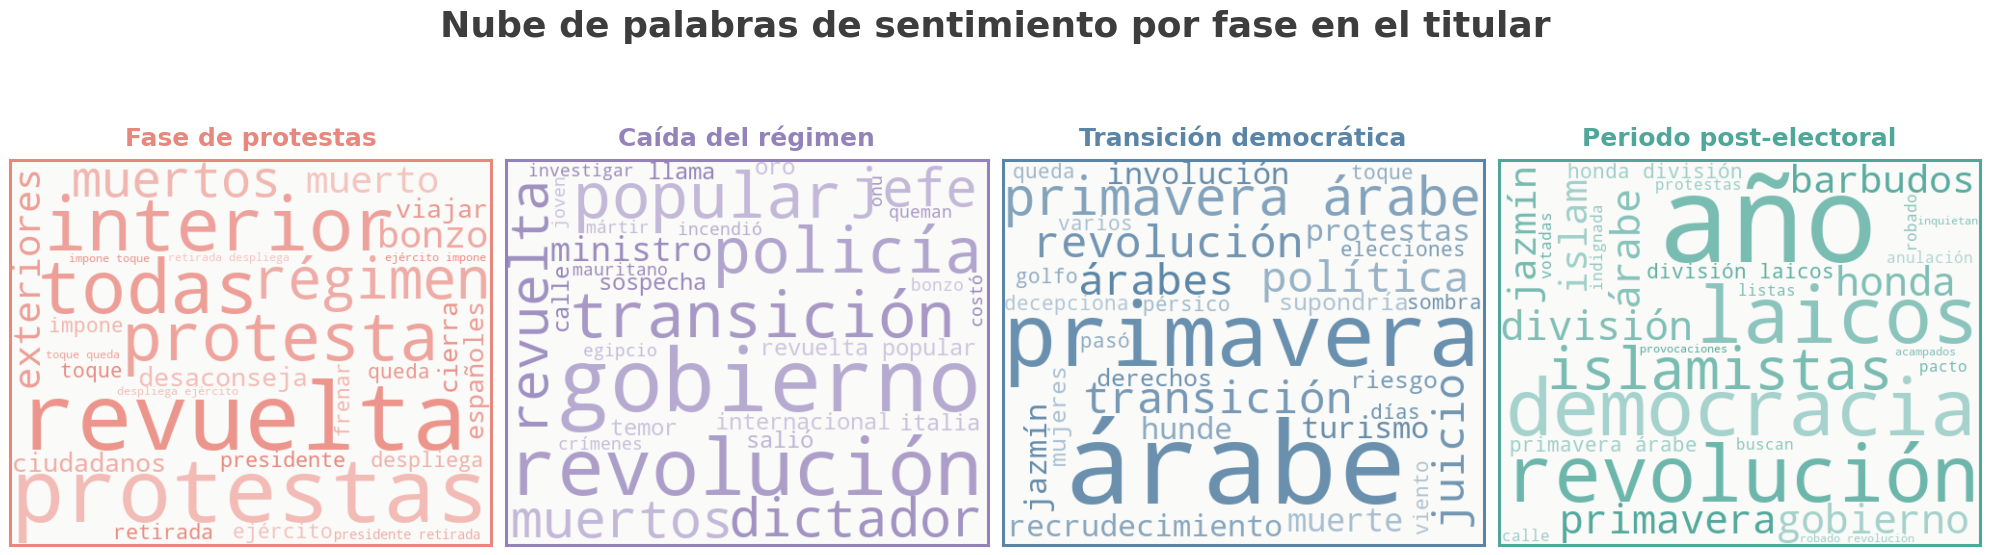

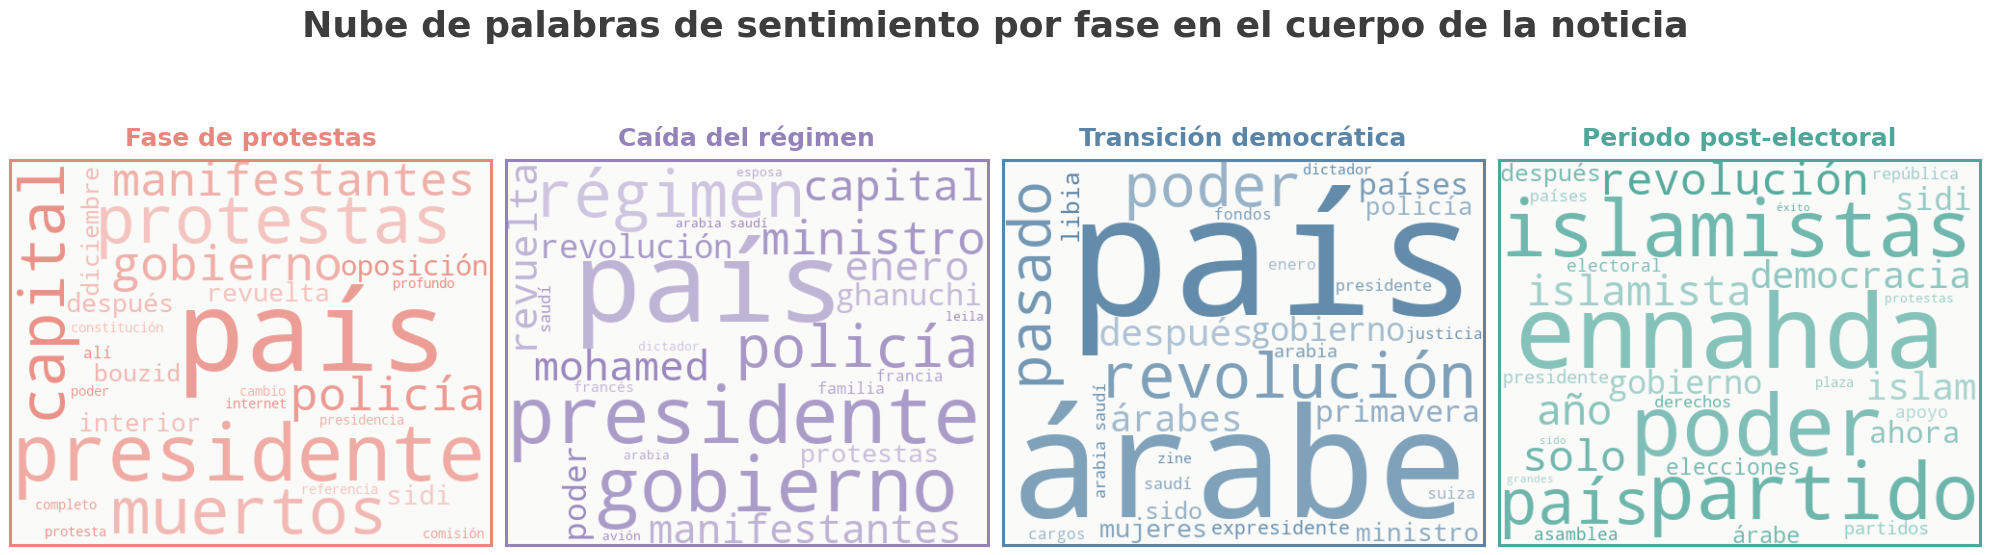

In [53]:
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

# ---- Paleta del proyecto ----
PALETA_FASES = {
    "Fase de protestas": "#E8877D",
    "Caída del régimen": "#9482BA",
    "Transición democrática": "#5B85A6",
    "Periodo post-electoral": "#4FA79A",
}
TINTES_FASES = {
    "Fase de protestas": "#F5C9C5",
    "Caída del régimen": "#CFC7E0",
    "Transición democrática": "#B5C8D7",
    "Periodo post-electoral": "#B0D7D2",
}
COLOR_TEXTO = "#3D3D3D"
COLOR_FONDO = "#FAFAF8"

def nubes_por_fase(df_ngramas, titulo_general):
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))

    for ax, fase in zip(axes, orden_fases):
        color_fase = PALETA_FASES[fase]
        tinte_fase = TINTES_FASES[fase]

        subset = df_ngramas[df_ngramas["fase"] == fase]
        frecuencias = dict(zip(subset["termino"], subset["freq_norm"]))

        if frecuencias:
            # Degradado propio de esta fase: del tinte claro al color fuerte,
            # así la palabra más frecuente destaca en el tono de marca más intenso
            cmap_fase = LinearSegmentedColormap.from_list(f"cmap_{fase}", [tinte_fase, color_fase])
            wc = WordCloud(width=500, height=400, background_color=COLOR_FONDO,
                            colormap=cmap_fase).generate_from_frequencies(frecuencias)
            ax.imshow(wc, interpolation="bilinear")

        ax.set_title(fase, fontsize=18, fontweight="bold", pad=10, color=color_fase)
        ax.set_xticks([])
        ax.set_yticks([])

        for borde in ax.spines.values():
            borde.set_visible(True)
            borde.set_color(color_fase)
            borde.set_linewidth(2.2)

    fig.suptitle(titulo_general, fontsize=26, fontweight="bold", color=COLOR_TEXTO, y=1.03)
    plt.tight_layout()
    plt.show()

nubes_por_fase(df_ngramas_titulo, "Nube de palabras de sentimiento por fase en el titular")
nubes_por_fase(df_ngramas_cuerpo, "Nube de palabras de sentimiento por fase en el cuerpo de la noticia")

## 7. ANÁLISIS DE EMOCIONES
Más allá del sentimiento (positivo/negativo), ¿qué emociones concretas (ira, tristeza, miedo...) predominan en la cobertura, y cómo evolucionan a lo largo de las fases?

Instalación del modelo Transformer entrenado para español.

El análisis de sentimientos y el análisis de emociones se realizan mediante la librería PySentimiento, basada en modelos Transformer. En español, estos modelos utilizan como arquitectura de referencia BETO, una adaptación de BERT preentrenada específicamente para español, posteriormente ajustada (fine-tuning) para tareas de clasificación de sentimientos y emociones. El análisis de sentimientos clasifica cada texto como positivo, negativo o neutral, mientras que el análisis de emociones estima la probabilidad de pertenencia a las categorías ira, asco, miedo, alegría, tristeza, sorpresa y una categoría residual («otras»).

In [54]:
from pysentimiento import create_analyzer

analizador_emociones = create_analyzer(task="emotion", lang="es")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [55]:
# PRUEBA 1 DE PREDICCIÓN DE EMOCIONES  
prueba = analizador_emociones.predict("La población tenía miedo y estaba desesperada.")
print(prueba)

AnalyzerOutput(output=fear, probas={fear: 0.881, others: 0.055, sadness: 0.034, surprise: 0.014, disgust: 0.008, joy: 0.005, anger: 0.003})


In [56]:
# PRUEBA 2 DE PREDICCIÓN DE EMOCIONES
prueba = analizador_emociones.predict("los talibanes prometen proteger los derechos de las mujeres y de las niñas en Afganistán.")
print(prueba)

AnalyzerOutput(output=others, probas={others: 0.970, anger: 0.008, joy: 0.007, disgust: 0.005, sadness: 0.004, fear: 0.003, surprise: 0.003})


## FUNCIÓN PARA EMOCIONES

Función para fragmentar el cuerpo en un máximo de 120 palabras

In [57]:
def dividir_en_fragmentos_emociones(texto, max_palabras=120):
    frases = sent_tokenize(str(texto), language="spanish")
    fragmentos, actual, n_palabras = [], [], 0

    for frase in frases:
        palabras_frase = len(frase.split())

        if actual and n_palabras + palabras_frase > max_palabras:
            fragmentos.append(" ".join(actual))
            actual, n_palabras = [], 0

        actual.append(frase)
        n_palabras += palabras_frase

    if actual:
        fragmentos.append(" ".join(actual))

    return fragmentos

Llamamiento de prueba

In [58]:
fragmentos_emociones = dividir_en_fragmentos_emociones(df_analisis.loc[0, "cuerpo_noticia"], max_palabras=120)
print(f"Número de fragmentos: {len(fragmentos_emociones)}")

Número de fragmentos: 35


Contruir un dataframe con los fragmentos del cuerpo y las emociones

In [59]:
filas_emociones = []

for _, row in df_analisis.iterrows():
    fragmentos = dividir_en_fragmentos_emociones(row["cuerpo_noticia"], max_palabras=120)

    for numero_fragmento, fragmento in enumerate(fragmentos, start=1):
        filas_emociones.append({"id_articulo": row["id_articulo"],
                                "fecha": row["fecha"],
                                "periodo_fase": row["periodo_fase"],
                                "numero_fragmento": numero_fragmento,
                                "texto_fragmento": fragmento})

df_emociones = pd.DataFrame(filas_emociones)

print(f"Fragmentos creados: {len(df_emociones)}")
df_emociones.head()

Fragmentos creados: 928


,id_articulo,fecha,periodo_fase,numero_fragmento,texto_fragmento
0,1,2011-01-23,Caída del régimen,1,La llama que incendió Túnez La inmolación del ...
1,1,2011-01-23,Caída del régimen,2,"El destino le escogió, sin embargo, y el 17 de..."
2,1,2011-01-23,Caída del régimen,3,"Mohamed vivía en el barrio de Hainur, donde to..."
3,1,2011-01-23,Caída del régimen,4,"Desde el mismo día en que Mohamed se inmoló, l..."
4,1,2011-01-23,Caída del régimen,5,"Estudiaba y trabajaba al mismo tiempo, pero nu..."


prueba sobre 5 fragmentos

In [60]:
for i, texto in enumerate(df_emociones["texto_fragmento"].head(5), start=1):
    resultado = analizador_emociones.predict(texto)
    print(f"Fragmento {i}: {resultado.output}")
    print(resultado.probas)
    print()

Fragmento 1: others
{'others': 0.5041534304618835, 'joy': 0.030697014182806015, 'sadness': 0.24747657775878906, 'anger': 0.1510148048400879, 'surprise': 0.006874431855976582, 'disgust': 0.05596759542822838, 'fear': 0.0038161377888172865}

Fragmento 2: sadness
{'others': 0.06313281506299973, 'joy': 0.0018258470809087157, 'sadness': 0.8900433778762817, 'anger': 0.02573375590145588, 'surprise': 0.002530535450205207, 'disgust': 0.012922978959977627, 'fear': 0.0038107193540781736}

Fragmento 3: others
{'others': 0.7151213884353638, 'joy': 0.011889664456248283, 'sadness': 0.2621849775314331, 'anger': 0.0033714056480675936, 'surprise': 0.0025829924270510674, 'disgust': 0.0033832681365311146, 'fear': 0.0014663436450064182}

Fragmento 4: others
{'others': 0.6241559386253357, 'joy': 0.0071164993569254875, 'sadness': 0.0696219950914383, 'anger': 0.24573549628257751, 'surprise': 0.01333850622177124, 'disgust': 0.034884944558143616, 'fear': 0.005146725103259087}

Fragmento 5: anger
{'others': 0.224

FUNCIÓN PARA OBTENER EMOCIONES 

In [61]:
def obtener_emociones(texto):
    r = analizador_emociones.predict(str(texto))
    return pd.Series({
        "emoción": r.output,
        "ira": r.probas["anger"],
        "asco": r.probas["disgust"],
        "miedo": r.probas["fear"],
        "alegría": r.probas["joy"],
        "tristeza": r.probas["sadness"],
        "sorpresa": r.probas["surprise"],
        "otras": r.probas["others"]})

df_emociones = pd.concat([df_emociones, df_emociones["texto_fragmento"].apply(obtener_emociones)],axis=1)

Comprobaciones de la función:

In [62]:
df_emociones.head(2)

,id_articulo,fecha,periodo_fase,numero_fragmento,texto_fragmento,emoción,ira,asco,miedo,alegría,tristeza,sorpresa,otras
0,1,2011-01-23,Caída del régimen,1,La llama que incendió Túnez La inmolación del ...,others,0.151015,0.055968,0.003816,0.030697,0.247477,0.006874,0.504153
1,1,2011-01-23,Caída del régimen,2,"El destino le escogió, sin embargo, y el 17 de...",sadness,0.025734,0.012923,0.003811,0.001826,0.890043,0.002531,0.063133


In [63]:
df_emociones["emoción"].value_counts()

emoción
others     552
anger      289
sadness     82
joy          5
Name: count, dtype: int64

In [64]:
df_emociones["emoción"].value_counts(normalize=True).mul(100).round(1)

emoción
others     59.5
anger      31.1
sadness     8.8
joy         0.5
Name: proportion, dtype: float64

In [65]:
#comprobar que las probabilidades suman aproximadamente 1:
columnas_emociones = ["ira", "asco", "miedo", "alegría", "tristeza", "sorpresa", "otras"]
df_emociones["suma_probabilidades"] = df_emociones[columnas_emociones].sum(axis=1)
df_emociones["suma_probabilidades"].describe()

count    9.280000e+02
mean     1.000000e+00
std      5.184301e-08
min      9.999999e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: suma_probabilidades, dtype: float64

In [66]:
#calculo de la media de la intensidad de cada emoción por artículo.
#Se agrupan los datos por artículo y se calcula la intensidad media de cada emoción (ira, asco, miedo, alegría, tristeza, sorpresa y otras), obteniendo un único registro representativo por artículo para facilitar el análisis posterior.
columnas_emociones = ["ira", "asco", "miedo", "alegría", "tristeza", "sorpresa", "otras"]
df_emociones_articulo = (df_emociones.groupby("id_articulo")[columnas_emociones].mean().reset_index())

In [67]:
#Recuperar la información del artículo
info_articulo = df_analisis[["id_articulo", "fecha", "periodo_fase", "titulo"]]
df_emociones_articulo = df_emociones_articulo.merge(info_articulo, on="id_articulo", how="left")
df_emociones_articulo.head()

,id_articulo,ira,asco,miedo,alegría,tristeza,sorpresa,otras,fecha,periodo_fase,titulo
0,1,0.329893,0.051293,0.005726,0.010438,0.160818,0.004244,0.437588,2011-01-23,Caída del régimen,La llama que incendió Túnez
1,2,0.367291,0.082328,0.041069,0.004233,0.151287,0.022823,0.330969,2011-01-17,Caída del régimen,Un egipcio y un mauritano se queman a lo bonzo
2,3,0.334261,0.061519,0.004728,0.003078,0.524403,0.003527,0.068485,2011-01-15,Caída del régimen,El joven mártir que cambió el destino de un país
3,4,0.522118,0.082056,0.007266,0.006609,0.177975,0.002072,0.201904,2011-06-13,Transición democrática,El viento de la 'primavera árabe'
4,5,0.345966,0.032359,0.006261,0.100744,0.220273,0.013042,0.281355,2011-10-11,Transición democrática,La 'primavera árabe' pasó


In [68]:
#Unir las emociones con las fases temporales

#emociones_fase como abla de apoyo: media de cada emoción por fase (no la emoción dominante, sino el promedio de probabilidad). 
#Se usa aquí solo para inspección visual antes de construir emocion_dominante; 

orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]
emociones_fase = (df_emociones_articulo.groupby("periodo_fase")[columnas_emociones].mean()).reindex(orden_fases)
emociones_fase

,ira,asco,miedo,alegría,tristeza,sorpresa,otras
periodo_fase,,,,,,,
Fase de protestas,0.262715,0.036759,0.012309,0.003029,0.130137,0.009074,0.545977
Caída del régimen,0.280556,0.042158,0.010693,0.007329,0.112119,0.006357,0.540788
Transición democrática,0.231020,0.044841,0.010251,0.012560,0.137057,0.008788,0.555483
Periodo post-electoral,0.213695,0.031182,0.003646,0.021538,0.084331,0.004081,0.641527


### PCA (Principal Component Analysis)
Se importa la librería scikit-learn y las herramientas StandardScaler, para estandarizar las variables, y PCA, para reducir la dimensionalidad de los datos y facilitar su análisis e interpretación.

In [69]:
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

**PCA sobre el perfil emocional de los artículos**

Las 6 emociones explícitas (ira, asco, miedo, alegría, tristeza, sorpresa) forman un espacio 
de 6 dimensiones por artículo, imposible de visualizar directamente. Se estandarizan estas 
variables (media 0, desviación 1) para que ninguna domine por escala, y se reduce el espacio 
a 2 componentes principales (PCA1, PCA2) que capturan la mayor variabilidad posible del 
conjunto original. Esto permite representar cada artículo como un punto en un plano 2D: 
artículos con perfiles emocionales similares aparecen cerca entre sí, y los distintos, lejos.

El PCA utiliza las puntuaciones de todas las emociones (ira, asco, miedo, alegría, tristeza y sorpresa) de cada artículo.
A partir de esas puntuaciones, reduce la información a dos componentes (PCA1 y PCA2) para representar cada artículo en un plano.

Se excluye otras del cálculo por no ser una emoción real (es "resto no clasificado").

La varianza explicada por los 2 componentes indica qué % de la información emocional original 
se conserva en la representación 2D; el resto se pierde en la reducción de dimensionalidad.

In [70]:
emociones_pca = ["ira", "asco", "miedo", "alegría", "tristeza", "sorpresa"]

X = df_emociones_articulo[emociones_pca]
X_escalado = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
coordenadas = pca.fit_transform(X_escalado)

df_emociones_articulo["PCA1"] = coordenadas[:, 0]
df_emociones_articulo["PCA2"] = coordenadas[:, 1]

print("Varianza explicada:", pca.explained_variance_ratio_.round(3))

Varianza explicada: [0.338 0.26 ]


- Cálculo de la emoción predominante e intensidad emocional

Se identifica la emoción predominante de cada artículo a partir de la emoción con mayor puntuación y se calcula una medida de intensidad emocional, utilizada posteriormente para el análisis y la representación visual de los resultados.

In [71]:
emociones_explicitas = ["ira", "asco", "miedo", "alegría", "tristeza", "sorpresa"]

df_emociones_articulo["emocion_dominante"] = df_emociones_articulo[emociones_explicitas].idxmax(axis=1)
df_emociones_articulo["intensidad_emocional"] = 1 - df_emociones_articulo["otras"]
df_emociones_articulo["intensidad_visual"] = (1 - df_emociones_articulo["otras"]) ** 2 * 100

df_emociones_articulo[["emocion_dominante", "intensidad_emocional"]].head()

,emocion_dominante,intensidad_emocional
0,ira,0.562412
1,ira,0.669031
2,tristeza,0.931515
3,ira,0.798096
4,ira,0.718645


VARIABLES NUEVAS - emoción dominante

**Nota sobre emocion_dominante:** esta variable se calcula únicamente sobre las 6 emociones 
explícitas (ira, asco, miedo, alegría, tristeza, sorpresa), excluyendo intencionadamente otras. 
Esto significa que a todo artículo se le asigna una emoción con nombre, incluso cuando otras 
tenga la probabilidad más alta (es decir, cuando el texto es predominantemente neutro o no 
tiene una carga emocional clara). Por eso se añade intensidad_emocional (1 - otras) como 
variable complementaria: permite matizar la lectura de emocion_dominante, ya que un valor 
bajo de intensidad indica que la "emoción dominante" asignada es poco representativa del 
contenido real del artículo.

GRÁFICO PCA: Representación de los perfiles emocionales mediante PCA

¿Cuál es la distribución de los articúlos según su intensidad emocional?

In [72]:
import plotly.express as px

colores_emociones_pca = {
    "ira": "#FA5252",
    "asco": "#9F80C9",
    "miedo": "#447385",
    "alegría": "#F4D35E",
    "tristeza": "#5287A8",
    "sorpresa": "#D381C3"
}

fig = px.scatter(
    df_emociones_articulo,
    x="PCA1", y="PCA2",
    color="emocion_dominante",
   size="intensidad_visual",
    size_max=24,
    color_discrete_map=colores_emociones_pca,
    hover_name="titulo",
    hover_data={
        "periodo_fase": True,
        "fecha": True,
        "emocion_dominante": True,
        "intensidad_emocional": ":.2f",
        "PCA1": False,
        "PCA2": False
    },
    labels={
        "emocion_dominante": "Emoción dominante",
        "intensidad_emocional": "Intensidad emocional",
        "periodo_fase": "Fase temporal"
    },
    title="Distribución de los artículos según su composición emocional e intensidad"
)

fig.update_traces(marker=dict(opacity=0.75, line=dict(width=0.6, color="white")))

fig.update_layout(
    xaxis_title=f"Componente 1 ({pca.explained_variance_ratio_[0] * 100:.1f} % de varianza)",
    yaxis_title=f"Componente 2 ({pca.explained_variance_ratio_[1] * 100:.1f} % de varianza)",
    legend_title="Emoción dominante",
    height=720
)

fig.show()

En la leyenda no se ven las emociones de  miedo, asco y sorpresa, estas sí pueden estar presentes con puntuaciones distintas de cero, pero nunca son la puntuación más alta en ningún artículo, por lo que no se consideran la emoción dominante.

In [73]:
df_emociones_articulo["emocion_dominante"].value_counts()

emocion_dominante
ira         98
tristeza    26
alegría      2
Name: count, dtype: int64

GRÁFICO: PODIO DE EMOCIONES DOMINANTES POR FASE
¿Qué emociones predominan a lo largo del conflicto?

In [74]:
#tabla de frecuencias
# % de artículos con cada emoción dominante, por fase
orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]

tabla_emocion_fase = pd.crosstab(df_emociones_articulo["periodo_fase"],df_emociones_articulo["emocion_dominante"],normalize="index") * 100

tabla_emocion_fase = tabla_emocion_fase.reindex(orden_fases)
tabla_emocion_fase.round(1)

emocion_dominante,alegría,ira,tristeza
periodo_fase,,,
Fase de protestas,0.0,69.2,30.8
Caída del régimen,0.0,82.4,17.6
Transición democrática,0.0,75.0,25.0
Periodo post-electoral,9.5,71.4,19.0


GRÁFICO EXPLORATORIO DE LÍNEAS: ¿Qué emociones son dominantes en el cuerpo de la noticia en cada fase?

In [75]:
import plotly.express as px

# Colores corporativos por emoción (misma familia que el resto del proyecto)
colores_emociones = {
    "ira": "#AE655E",
    "tristeza": "#5B85A6",
    "alegría": "#D4B96A",
    "miedo": "#8C99A6",
    "asco": "#9482BA",
    "sorpresa": "#4FA79A",
}

COLOR_TEXTO = "#3D3D3D"
COLOR_GRIS = "#6B6B6B"

# Pasar la tabla a formato largo
df_plot = (
    tabla_emocion_fase
    .reset_index()
    .melt(
        id_vars="periodo_fase",
        var_name="emocion",
        value_name="porcentaje"
    )
)

# Etiqueta de texto ya formateada, lista para mostrar sobre cada punto
df_plot["etiqueta_pct"] = df_plot["porcentaje"].round(1).astype(str) + "%"

fig = px.line(
    df_plot,
    x="periodo_fase",
    y="porcentaje",
    color="emocion",
    markers=True,
    text="etiqueta_pct",
    color_discrete_map=colores_emociones,
    title="Evolución de la emoción dominante por fase"
)

fig.update_traces(
    mode="lines+markers+text",
    line=dict(width=3),
    marker=dict(size=9),
    textposition="top center",
    textfont=dict(size=11, weight="bold"),
)

# Cada etiqueta de texto toma el mismo color que su propia línea/marcador
fig.for_each_trace(lambda t: t.update(textfont_color=t.line.color))

fig.update_layout(
    xaxis_title="",
    yaxis_title="% de artículos",
    legend_title="Emoción dominante",
    height=650,
    template="simple_white",
    font=dict(color=COLOR_TEXTO),
    title_font=dict(color=COLOR_TEXTO, size=20),
    legend_font=dict(color=COLOR_TEXTO),
    plot_bgcolor="#FFFFFF",
    paper_bgcolor="#FFFFFF",
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="rgba(200,200,200,0.35)",
    tickfont=dict(color=COLOR_GRIS)
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="rgba(200,200,200,0.35)",
    tickfont=dict(color=COLOR_GRIS)
)

etiquetas_fases = [
    "Fase de protestas<br><sup>17/12/2010 – 13/01/2011</sup>",
    "Caída del régimen<br><sup>14/01/2011 – 28/02/2011</sup>",
    "Transición democrática<br><sup>01/03/2011 – 22/10/2011</sup>",
    "Periodo post-electoral<br><sup>23/10/2011 – 31/12/2011</sup>"
]

fig.update_xaxes(
    tickmode="array",
    tickvals=orden_fases,
    ticktext=etiquetas_fases
)

fig.show()

### ANÁLISIS DE COOCURRENCIAS

Configuración de actores y sus variantes

In [76]:
actores_institucionales = { "Ben Ali": ["zine el abidine ben ali", "zine el-abidine ben ali", "ben ali"],
            "Bouazizi": ["mohamed bouazizi", "bouazizi"],
            "Ennahda": ["movimiento ennahda", "partido ennahda", "ennahda", "nahda"],
            "Ejército": ["fuerzas armadas", "ejército", "militares"],
            "Policía": ["fuerzas de seguridad", "policía", "policías", "agentes"],
            "Población tunecina": ["tunecinos", "tunecinas", "población tunecina", "pueblo tunecino", "ciudadanos tunecinos"],
            "Jóvenes": ["jóvenes", "juventud", "estudiantes", "universitarios"]}

Función para el recuento de menciones de los actores 

In [77]:
import re

def contar_menciones_actor(texto, variantes):
    texto = str(texto).lower()
    variantes_ordenadas = sorted(variantes, key=len, reverse=True)
    patron = re.compile(r"\b(?:" + "|".join(re.escape(v) for v in variantes_ordenadas) + r")\b")
    return len(patron.findall(texto))

Comprobar frecuencia en el corpus para actores institucionales

In [78]:
for actor, variantes in actores_institucionales.items():
    menciones = df_analisis["cuerpo_noticia"].apply(lambda texto: contar_menciones_actor(texto, variantes)).sum()
    articulos = df_analisis["cuerpo_noticia"].apply(lambda texto: contar_menciones_actor(texto, variantes) > 0).sum()
    print(f"{actor}: {menciones} menciones en {articulos} artículos")

Ben Ali: 497 menciones en 101 artículos
Bouazizi: 60 menciones en 32 artículos
Ennahda: 94 menciones en 27 artículos
Ejército: 127 menciones en 46 artículos
Policía: 231 menciones en 75 artículos
Población tunecina: 187 menciones en 78 artículos
Jóvenes: 114 menciones en 59 artículos


### Función para el cálculo de coocurrencias de actores

Se define una función que identifica las menciones de cada actor y extrae las palabras que aparecen en una ventana de contexto alrededor de ellas. Posteriormente, contabiliza la frecuencia de esas coocurrencias para analizar los términos más asociados a cada actor en el corpus.

In [79]:
from collections import Counter
import re

def coocurrencias_actor(textos, variantes, ventana=10):
    conteos = Counter()
    variantes_ordenadas = sorted(variantes, key=lambda x: len(x.split()), reverse=True)

    for texto in textos.dropna():
        tokens = re.findall(r"\b[a-záéíóúüñ]+\b", str(texto).lower())
        i = 0
        while i < len(tokens):
            coincidencia = None
            for variante in variantes_ordenadas:
                partes = variante.split()
                if tokens[i:i + len(partes)] == partes:
                    coincidencia = partes
                    break

            if coincidencia:
                inicio = max(0, i - ventana)
                fin = min(len(tokens), i + len(coincidencia) + ventana)
                contexto = tokens[inicio:i] + tokens[i + len(coincidencia):fin]
                for palabra in contexto:
                    if palabra not in stop_coocurrencias and len(palabra) > 2:
                        conteos[palabra] += 1
                i += len(coincidencia)
            else:
                i += 1

    return conteos

Definición de las palabras vacías (stopwords) - Se carga el conjunto de stopwords en español y se amplía con un listado personalizado de términos frecuentes o poco informativos, con el objetivo de excluirlos del análisis y centrar los resultados en las palabras con mayor valor semántico.

In [80]:
stop = set(stopwords.words("spanish"))
stop.update(extra)

In [81]:
stop_coocurrencias = stop.union({
    "país", "enero", "diciembre", "pasado", "después", "ahora", "sido",
    "primeras", "gobierno", "ministro", "jefe", "formación", "ammar", "mientras", "gran", "interior"})

- Cálculo de las coocurrencias por 

Se calculan las coocurrencias léxicas de cada actor institucional analizando las palabras que aparecen en su contexto dentro del cuerpo de las noticias. Los resultados se almacenan en un diccionario para su posterior análisis y visualización

In [82]:
coocurrencias_actores = {}

for actor, variantes in actores_institucionales.items():
    coocurrencias_actores[actor] = coocurrencias_actor(df_analisis["cuerpo_noticia"],variantes,ventana=10)

PRUEBA: Analizar las 15 coocurrencias más frecuentes

In [83]:
for actor, conteos in coocurrencias_actores.items():
    print(f"\n{actor}")
    print(conteos.most_common(15))


Ben Ali
[('presidente', 99), ('régimen', 42), ('poder', 31), ('dictador', 31), ('saudí', 27), ('partido', 27), ('trabelsi', 27), ('revuelta', 26), ('esposa', 26), ('arabia', 25), ('familia', 19), ('policía', 19), ('constitucional', 18), ('leila', 18), ('huida', 18)]

Bouazizi
[('bouzid', 24), ('sidi', 23), ('joven', 12), ('fuego', 10), ('inmoló', 10), ('protestas', 7), ('hospital', 6), ('falleció', 6), ('acto', 5), ('vendedor', 4), ('frutas', 4), ('revuelta', 4), ('héroe', 4), ('bonzo', 4), ('año', 4)]

Ennahda
[('partido', 23), ('islamista', 21), ('renacimiento', 15), ('islamistas', 15), ('elecciones', 13), ('líder', 9), ('rachid', 8), ('exilio', 7), ('partidos', 7), ('ganó', 6), ('sufragios', 6), ('electoral', 6), ('islámico', 5), ('asamblea', 5), ('victoria', 5)]

Ejército
[('policía', 12), ('poder', 11), ('presencia', 9), ('ejército', 7), ('capital', 7), ('orden', 6), ('manifestantes', 6), ('revolución', 6), ('calles', 6), ('militares', 5), ('casi', 5), ('soldados', 5), ('presiden

#### CONSTRUCCIÓN DE LA RED NETWORKX A TRAVÉS DE LAS COOCURRENCIAS

Creación del grafo de coocurrencias

In [84]:

import networkx as nx
G = nx.Graph()
TOP = 10 #10 palabras más frecuentes de cada actor también son nodos

for actor, conteos in coocurrencias_actores.items():
    G.add_node(actor, tipo="actor")    #actores como nodos

    for palabra, frecuencia in conteos.most_common(TOP):
        G.add_node(palabra, tipo="palabra")
        G.add_edge(actor, palabra, weight=frecuencia)

El grafo es bipartito: tiene dos tipos de nodos distintos:as aristas siempre conectan un actor con una palabra, nunca actor-actor ni palabra-palabra.

In [85]:
print(f"Nodos: {G.number_of_nodes()}")
print(f"Aristas: {G.number_of_edges()}")

Nodos: 58
Aristas: 70


Se construye un grafo de coocurrencias en el que cada actor institucional y sus términos más frecuentemente asociados se representan como nodos. Las conexiones entre ellos se establecen mediante aristas cuyo peso corresponde a la frecuencia de coocurrencia, permitiendo analizar visualmente las relaciones léxicas presentes en el corpus.

### GRÁFICO: Representación gráfica del grafo de coocurrencias

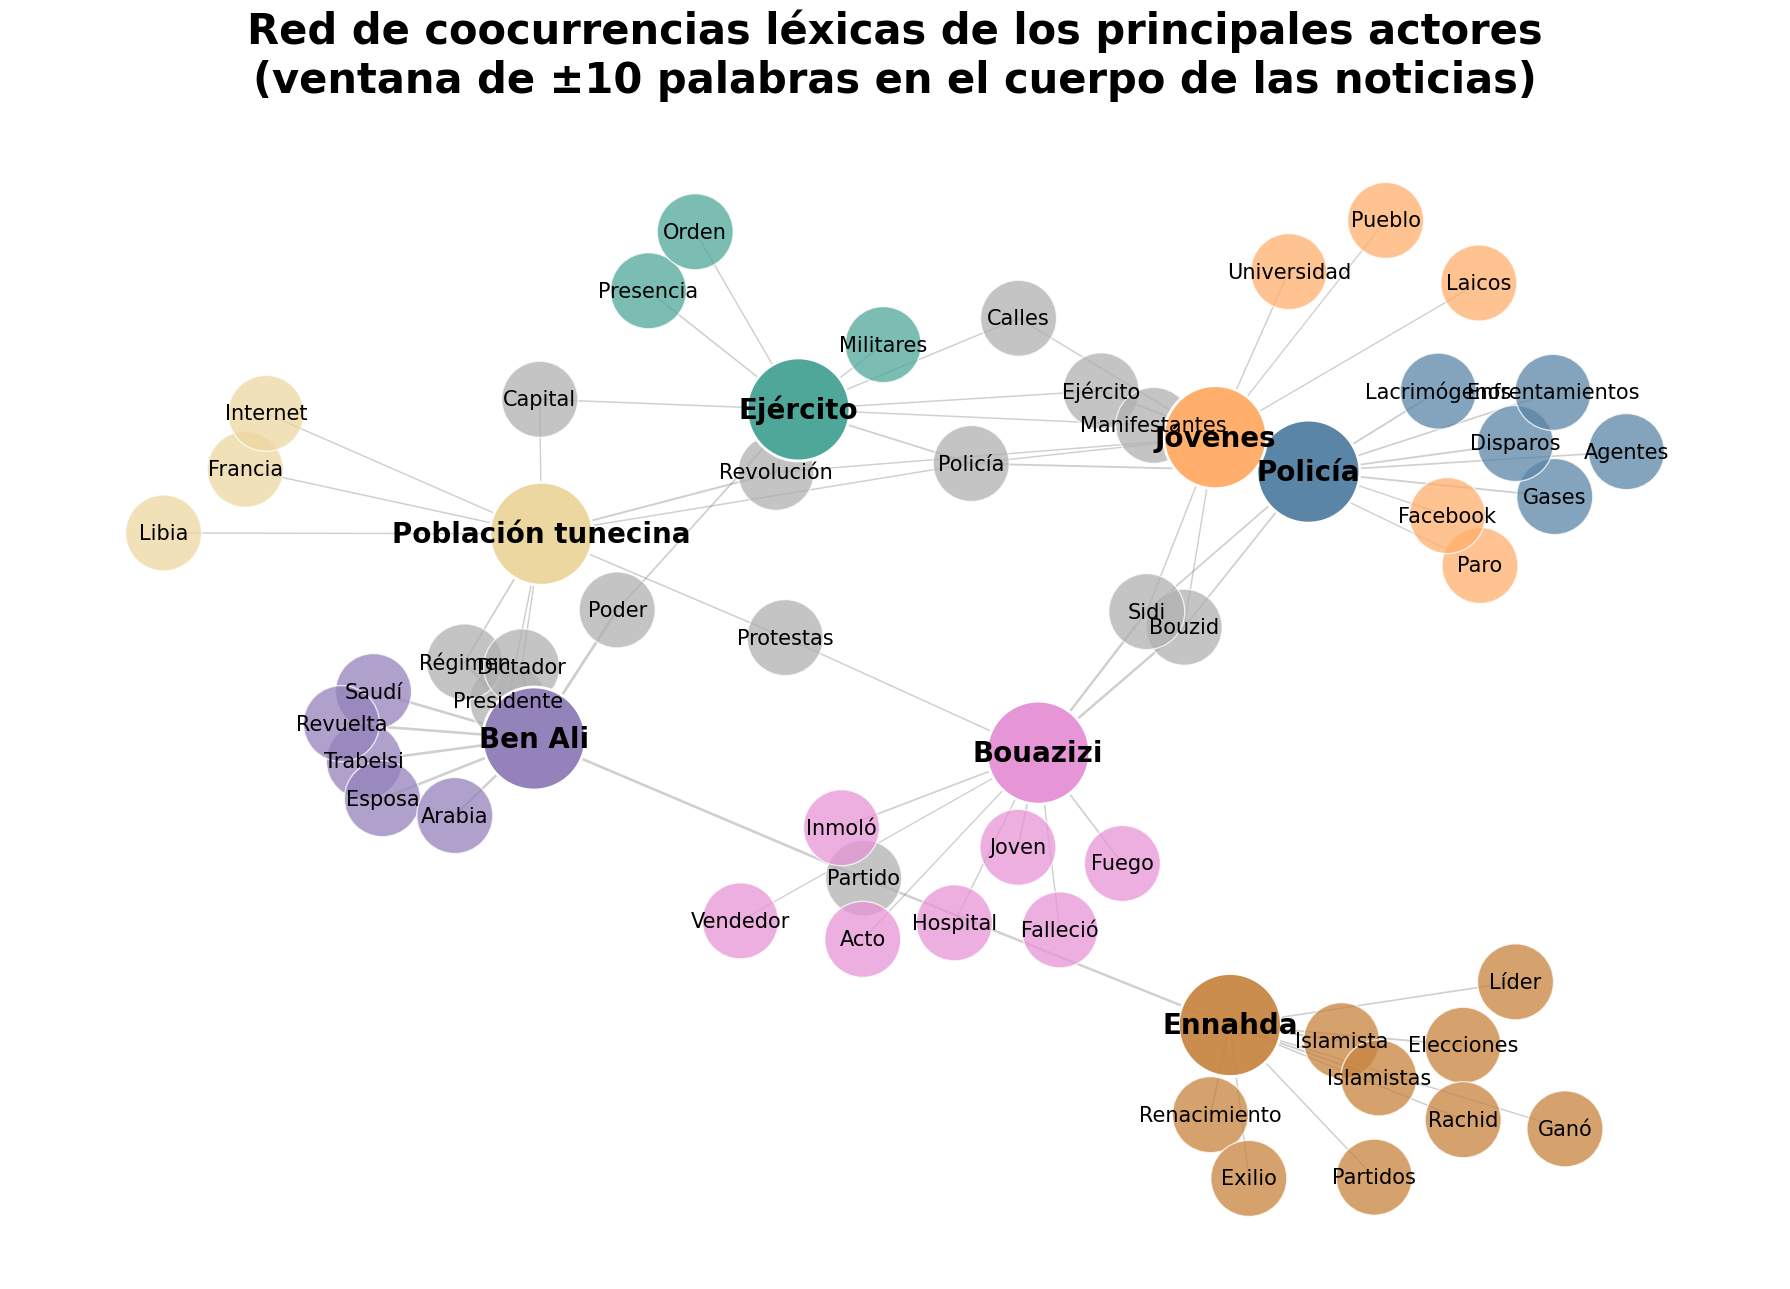

In [86]:
import matplotlib.pyplot as plt
import networkx as nx

colores_actores = {
    "Ben Ali": "#9482BA",
    "Bouazizi": "#E695D6",
    "Ennahda": "#C7833EEA",
    "Ejército":  "#4FA79A",
    "Policía":  "#5B85A6",
    "Población tunecina": "#EDD7A1",
    "Jóvenes": "#FFAE6C"}

pos = nx.spring_layout(G, seed=42, k=1.1, iterations=150)

nodos_actores = [n for n, datos in G.nodes(data=True) if datos["tipo"] == "actor"]
nodos_palabras = [n for n, datos in G.nodes(data=True) if datos["tipo"] == "palabra"]

colores_palabras = []
for palabra in nodos_palabras:
    actores_conectados = [n for n in G.neighbors(palabra) if n in actores_institucionales]
    colores_palabras.append(colores_actores[actores_conectados[0]] if len(actores_conectados) == 1 else "#B0B0B0")

pesos = [G[u][v]["weight"] for u, v in G.edges()]
peso_maximo = max(pesos)
anchos = [0.8 + 4 * peso / peso_maximo for peso in pesos]

fig, ax = plt.subplots(figsize=(18, 13))

nx.draw_networkx_edges(G, pos, width=anchos, alpha=0.35, edge_color="#777777", ax=ax)

nx.draw_networkx_nodes( G, pos, nodelist=nodos_palabras, node_size=3000,
                        node_color=colores_palabras, alpha=0.75,
                        edgecolors="white", linewidths=1, ax=ax)

nx.draw_networkx_nodes(G, pos, nodelist=nodos_actores, node_size=5500,
                        node_color=[colores_actores[n] for n in nodos_actores],
                        edgecolors="white", linewidths=2, ax=ax)

nx.draw_networkx_labels(G, pos,labels={n: n.capitalize() for n in nodos_palabras},
                        font_size=15, font_color="black", ax=ax)

nx.draw_networkx_labels(G, pos,labels={n: n for n in nodos_actores},
    font_size=20, font_weight="bold", font_color="black", ax=ax)

ax.set_title("Red de coocurrencias léxicas de los principales actores\n"
            "(ventana de ±10 palabras en el cuerpo de las noticias)",
            fontsize=30, fontweight="bold", pad=20)

ax.axis("off")
plt.tight_layout()
plt.show()

Se representa la red de coocurrencias mediante un grafo en el que los actores institucionales y las palabras asociadas aparecen como nodos conectados por aristas. El color de los nodos identifica al actor al que se asocian los términos, mientras que el grosor de las conexiones refleja la frecuencia de coocurrencia entre ambos, facilitando la interpretación de las relaciones léxicas presentes en el corpus

OTRAS VISUALIZACIONES:

### GRÁFICO:  Cantidad de artículos por fase temporal 

In [87]:
import plotly.express as px
import pandas as pd

orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]

FASES_FECHAS = {
    "Fase de protestas": "17/12/2010 – 13/01/2011",
    "Caída del régimen": "14/01/2011 – 28/02/2011",
    "Transición democrática": "01/03/2011 – 22/10/2011",
    "Periodo post-electoral": "23/10/2011 – 31/12/2011",
}

# Cantidad de artículos por fase
articulos_por_fase = df_analisis["periodo_fase"].value_counts().reindex(orden_fases).reset_index()
articulos_por_fase.columns = ["fase", "cantidad"]

# Etiqueta con la fecha de FASES_FECHAS (ya no calculada desde los datos)
articulos_por_fase["rango_texto"] = articulos_por_fase["fase"].map(FASES_FECHAS)
articulos_por_fase["fase_etiqueta"] = articulos_por_fase["fase"] + "<br><span style='font-size:11px;color:gray'>" + articulos_por_fase["rango_texto"] + "</span>"

orden_etiquetas = articulos_por_fase.set_index("fase").loc[orden_fases, "fase_etiqueta"].tolist()

colores_fases = {
    "Fase de protestas": "#F27272",
    "Caída del régimen": "#9F80C9",
    "Transición democrática": "#457B9D",
    "Periodo post-electoral": "#2A9D8F"}
colores_fases_etiqueta = {row["fase_etiqueta"]: colores_fases[row["fase"]] for _, row in articulos_por_fase.iterrows()}

fig = px.scatter(
    articulos_por_fase,
    x="cantidad",
    y="fase_etiqueta",
    color="fase_etiqueta",
    size="cantidad",
    size_max=40,
    color_discrete_map=colores_fases_etiqueta,
    text="cantidad",
    category_orders={"fase_etiqueta": orden_etiquetas},
    title="Cantidad de artículos por fase temporal"
)

for _, row in articulos_por_fase.iterrows():
    fig.add_shape(
        type="line",
        x0=0, x1=row["cantidad"],
        y0=row["fase_etiqueta"], y1=row["fase_etiqueta"],
        line=dict(color=colores_fases[row["fase"]], width=3)
    )

fig.update_traces(textposition="middle right", textfont=dict(size=14, color="black"))
fig.update_layout(
    xaxis_title="Número de artículos",
    yaxis_title="",
    yaxis=dict(categoryorder="array", categoryarray=orden_etiquetas[::-1]),
    showlegend=False,
    height=480,
    plot_bgcolor="white"
)
fig.update_xaxes(showgrid=True, gridcolor="#EEEEEE")

fig.show()

### GRÁFICO PRESENTACIÓN: HITOS CLAVE DE LA REVOLUCIÓN TUNECINA

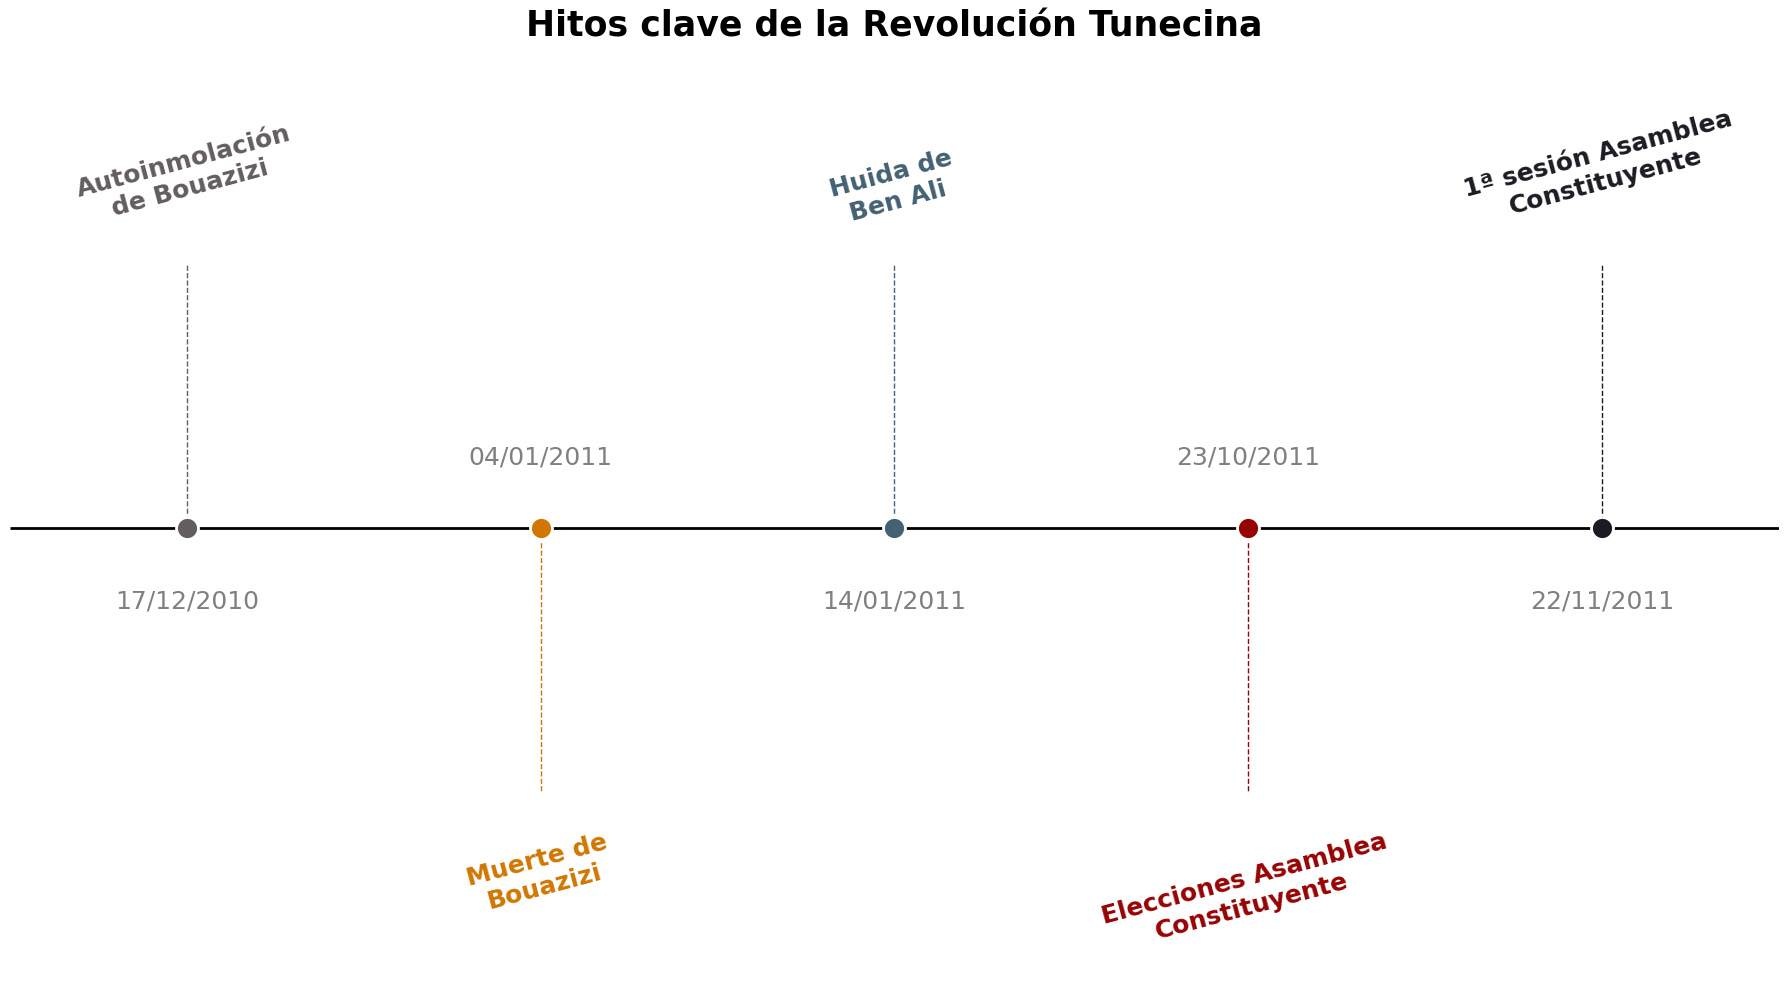

In [88]:
import matplotlib.pyplot as plt

eventos_historicos = {
    "Autoinmolación\nde Bouazizi": "2010-12-17",
    "Muerte de\nBouazizi": "2011-01-04",
    "Huida de\nBen Ali": "2011-01-14",
    "Elecciones Asamblea\nConstituyente": "2011-10-23",
    "1ª sesión Asamblea\nConstituyente": "2011-11-22",
}
colores_eventos = ["#645D5D", "#D07703", "#436173", "#970303", "#1D1A23"]

fig, ax = plt.subplots(figsize=(18, 10))

x_posiciones = range(len(eventos_historicos))
ax.hlines(0, -0.5, len(eventos_historicos) - 0.5, color="black", linewidth=2, zorder=1)

for i, (nombre, fecha) in enumerate(eventos_historicos.items()):
    color = colores_eventos[i]
    ax.scatter(i, 0, s=250, color=color, zorder=3, edgecolors="white", linewidths=2)

    # alterna etiquetas arriba/abajo para dar más aire
    y_texto = 0.35 if i % 2 == 0 else -0.35
    ax.plot([i, i], [0, y_texto], color=color, linewidth=1, linestyle="--", zorder=2)
    ax.text(i, y_texto + (0.05 if i % 2 == 0 else -0.05), nombre,
            ha="center", va="bottom" if i % 2 == 0 else "top",
            fontsize=18, fontweight="bold", color=color, rotation=15)

    fecha_fmt = pd.to_datetime(fecha).strftime("%d/%m/%Y")
    ax.text(i, -0.08 if i % 2 == 0 else 0.08, fecha_fmt,
            ha="center", va="top" if i % 2 == 0 else "bottom", fontsize=18, color="gray")

ax.set_xlim(-0.5, len(eventos_historicos) - 0.5)
ax.set_ylim(-0.6, 0.6)
ax.axis("off")
ax.set_title("Hitos clave de la Revolución Tunecina", fontsize=25, fontweight="bold", pad=30)
plt.tight_layout()
plt.show()

### 3. GRÁFICO: Análisis temporal de la cobertura en torno a los principales acontecimientos

¿La cobertura fue puntual o se adelantó atrasó a los eventos?

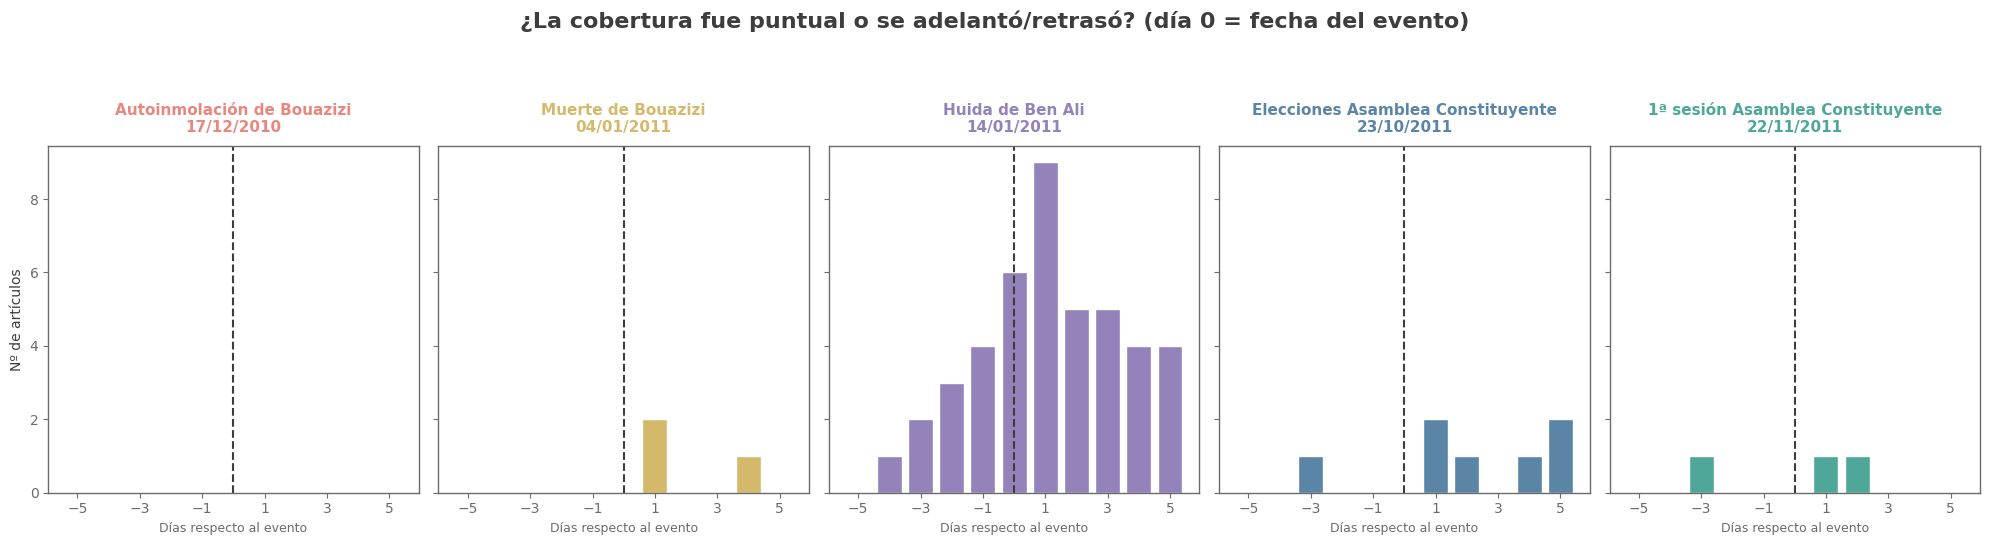

In [89]:
import matplotlib.pyplot as plt
import pandas as pd

# ---- Paleta corporativa, un tono por hito ----
colores_eventos = ["#E8877D", "#D4B96A", "#9482BA", "#5B85A6", "#4FA79A"]
COLOR_TEXTO = "#3D3D3D"
COLOR_GRIS = "#6B6B6B"

ventana_dias = 5
fig, axes = plt.subplots(1, len(eventos_historicos), figsize=(20, 5), sharey=True)
fig.patch.set_facecolor("white")

for ax, ((nombre, fecha), color) in zip(axes, zip(eventos_historicos.items(), colores_eventos)):
    fecha_evento = pd.to_datetime(fecha)
    inicio = fecha_evento - pd.Timedelta(days=ventana_dias)
    fin = fecha_evento + pd.Timedelta(days=ventana_dias)

    subset = df_analisis[(df_analisis["fecha"] >= inicio) & (df_analisis["fecha"] <= fin)]
    offset_dias = (subset["fecha"] - fecha_evento).dt.days
    conteo_por_dia = offset_dias.value_counts().reindex(range(-ventana_dias, ventana_dias + 1), fill_value=0)

    ax.set_facecolor("white")
    ax.bar(conteo_por_dia.index, conteo_por_dia.values, color=color, edgecolor="white")
    ax.axvline(0, color=COLOR_TEXTO, linewidth=1.5, linestyle="--")

    ax.set_title(f"{nombre.replace(chr(10), ' ')}\n{fecha_evento.strftime('%d/%m/%Y')}",
                 fontsize=11, fontweight="bold", color=color, pad=10)
    ax.set_xlabel("Días respecto al evento", fontsize=9, color=COLOR_GRIS)
    ax.set_xticks(range(-ventana_dias, ventana_dias + 1, 2))
    ax.tick_params(colors=COLOR_GRIS)

    # Caja cerrada: las 4 líneas visibles, en gris de marca
    for borde in ax.spines.values():
        borde.set_visible(True)
        borde.set_color(COLOR_GRIS)
        borde.set_linewidth(1)

axes[0].set_ylabel("Nº de artículos", fontsize=10, color=COLOR_TEXTO)
fig.suptitle("¿La cobertura fue puntual o se adelantó/retrasó? (día 0 = fecha del evento)",
             fontsize=16, fontweight="bold", color=COLOR_TEXTO, y=1.08)
plt.tight_layout()
plt.show()

4. GRÁFICO PRESENTACIÓN: Contexto temporal y fases 

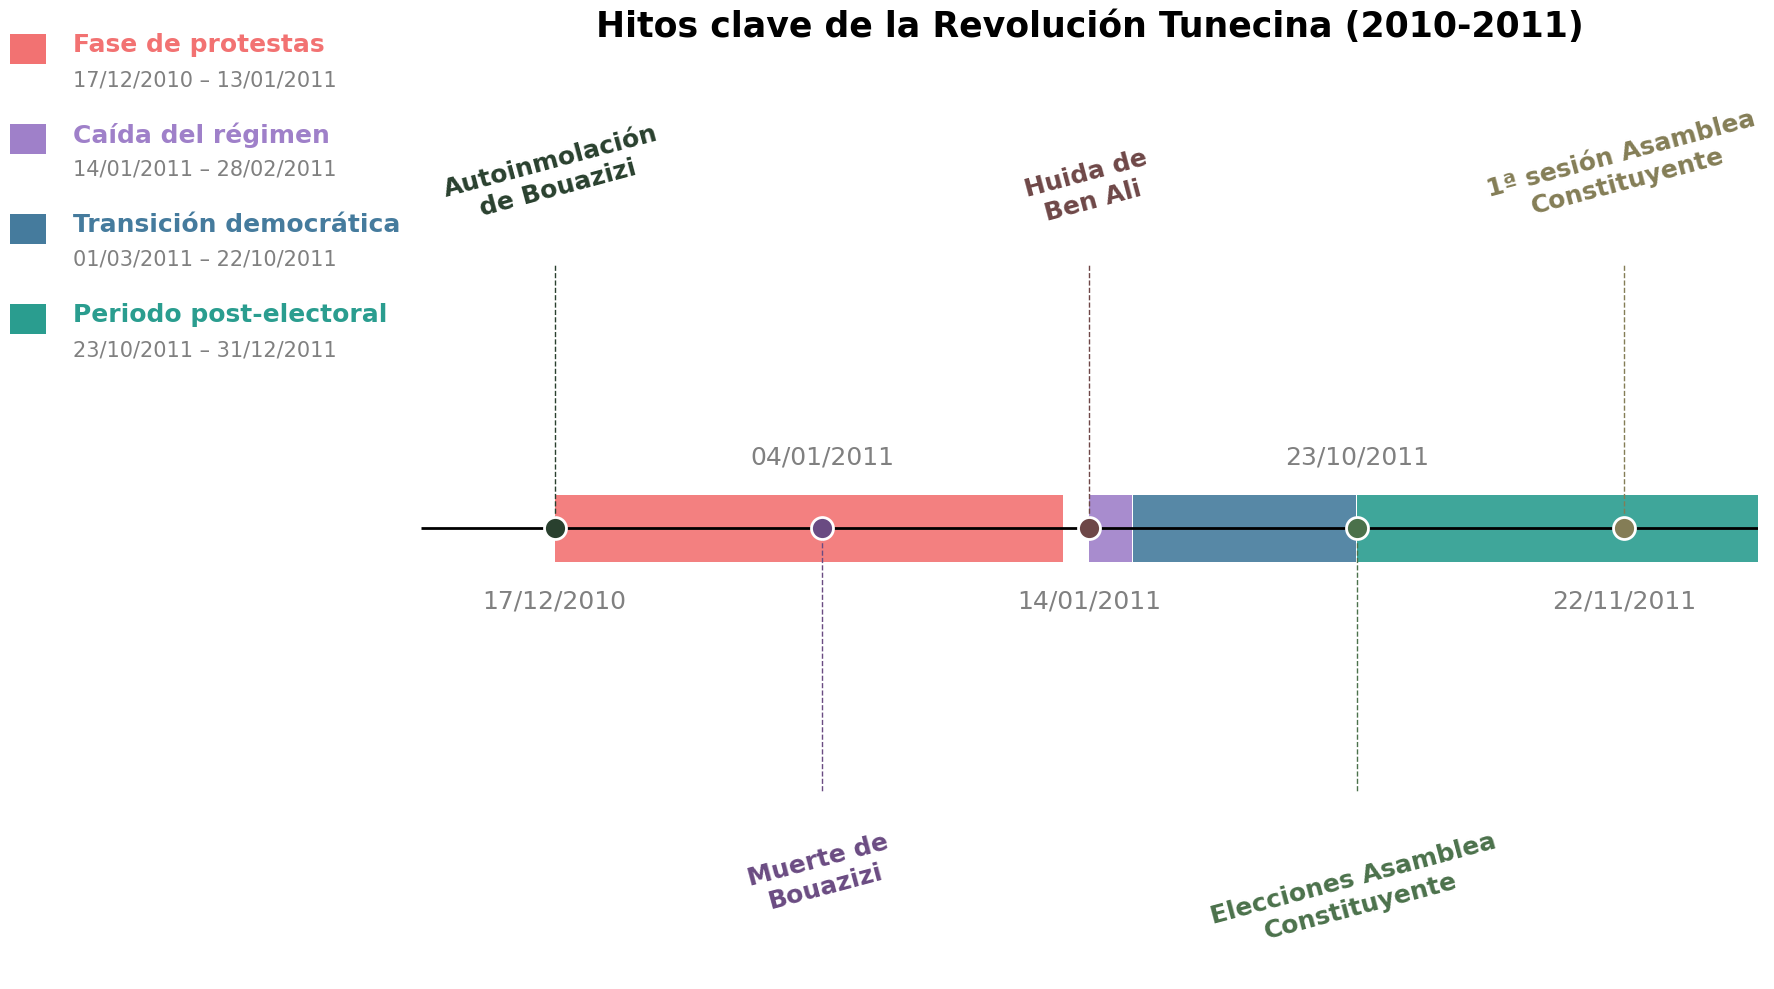

In [130]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np

eventos_historicos = {
    "Autoinmolación\nde Bouazizi": "2010-12-17",
    "Muerte de\nBouazizi": "2011-01-04",
    "Huida de\nBen Ali": "2011-01-14",
    "Elecciones Asamblea\nConstituyente": "2011-10-23",
    "1ª sesión Asamblea\nConstituyente": "2011-11-22",
}
colores_eventos = ["#29402E", "#6A4B82", "#6E4747", "#4B714B", "#847D56"]

orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]
colores_fases = {
    "Fase de protestas": "#F27272",
    "Caída del régimen": "#9F80C9",
    "Transición democrática": "#457B9D",
    "Periodo post-electoral": "#2A9D8F"
}

FASES_FECHAS = {
    "Fase de protestas": "17/12/2010 – 13/01/2011",
    "Caída del régimen": "14/01/2011 – 28/02/2011",
    "Transición democrática": "01/03/2011 – 22/10/2011",
    "Periodo post-electoral": "23/10/2011 – 31/12/2011",
}

# Convertir FASES_FECHAS (texto) a un DataFrame con min/max como fechas reales,
# para que el resto del código (fecha_a_x, strftime, etc.) no tenga que cambiar
rango_fechas = pd.DataFrame({
    fase: {
        "min": pd.to_datetime(rango.split(" – ")[0], format="%d/%m/%Y"),
        "max": pd.to_datetime(rango.split(" – ")[1], format="%d/%m/%Y"),
    }
    for fase, rango in FASES_FECHAS.items()
}).T.reindex(orden_fases)

# --- Traducir fechas de fase a posiciones X sobre TU mismo eje (0,1,2,3,4 = eventos) ---
ordinales_eventos = [pd.to_datetime(f).toordinal() for f in eventos_historicos.values()]
x_eventos = list(range(len(eventos_historicos)))

def fecha_a_x(fecha):
    ordinal = pd.to_datetime(fecha).toordinal()
    if ordinal <= ordinales_eventos[0]:
        pendiente = (x_eventos[1] - x_eventos[0]) / (ordinales_eventos[1] - ordinales_eventos[0])
        return x_eventos[0] + pendiente * (ordinal - ordinales_eventos[0])
    if ordinal >= ordinales_eventos[-1]:
        pendiente = (x_eventos[-1] - x_eventos[-2]) / (ordinales_eventos[-1] - ordinales_eventos[-2])
        return x_eventos[-1] + pendiente * (ordinal - ordinales_eventos[-1])
    return float(np.interp(ordinal, ordinales_eventos, x_eventos))

fig, ax = plt.subplots(figsize=(18, 10))

# --- BLOQUES DE FASE: rectángulos sólidos, banda estrecha alrededor de la línea (estilo Bauhaus) ---
altura_bloque = 0.09
for fase in orden_fases:
    x_inicio = fecha_a_x(rango_fechas.loc[fase, "min"])
    x_fin = fecha_a_x(rango_fechas.loc[fase, "max"])
    rect = patches.Rectangle(
        (x_inicio, -altura_bloque / 2), x_fin - x_inicio, altura_bloque,
        facecolor=colores_fases[fase], edgecolor="none", zorder=0, alpha=0.9
    )
    ax.add_patch(rect)

# --- Tu línea y eventos, sin tocar ---
x_posiciones = range(len(eventos_historicos))
ax.hlines(0, -0.5, len(eventos_historicos) - 0.5, color="black", linewidth=2, zorder=2)

for i, (nombre, fecha) in enumerate(eventos_historicos.items()):
    color = colores_eventos[i]
    ax.scatter(i, 0, s=250, color=color, zorder=3, edgecolors="white", linewidths=2)

    y_texto = 0.35 if i % 2 == 0 else -0.35
    ax.plot([i, i], [0, y_texto], color=color, linewidth=1, linestyle="--", zorder=2)
    ax.text(i, y_texto + (0.05 if i % 2 == 0 else -0.05), nombre,
            ha="center", va="bottom" if i % 2 == 0 else "top",
            fontsize=18, fontweight="bold", color=color, rotation=15)

    fecha_fmt = pd.to_datetime(fecha).strftime("%d/%m/%Y")
    ax.text(i, -0.08 if i % 2 == 0 else 0.08, fecha_fmt,
            ha="center", va="top" if i % 2 == 0 else "bottom", fontsize=18, color="gray")

ax.set_xlim(-0.5, len(eventos_historicos) - 0.5)
ax.set_ylim(-0.6, 0.6)
ax.axis("off")
ax.set_title("Hitos clave de la Revolución Tunecina (2010-2011)", fontsize=25, fontweight="bold", pad=30)

# --- LEYENDA a la izquierda: cuadrado de color + nombre + rango de fechas (desde FASES_FECHAS) ---
y_leyenda_inicio = 0.95
for idx, fase in enumerate(orden_fases):
    y = y_leyenda_inicio - idx * 0.09
    rango_texto = FASES_FECHAS[fase]   # <- directamente del diccionario, ya no recalculado

    fig.patches.append(patches.Rectangle(
        (0.02, y - 0.02), 0.02, 0.03, transform=fig.transFigure,
        facecolor=colores_fases[fase], edgecolor="none"
    ))
    fig.text(0.055, y, fase, fontsize=18, fontweight="bold", color=colores_fases[fase], va="center")
    fig.text(0.055, y - 0.035, rango_texto, fontsize=15, color="gray", va="center")

plt.tight_layout(rect=[0.24, 0, 1, 1])
plt.show()

5. Representación cartográfica sobre la geografía que aparece en los artículos

In [117]:
# Ver qué lugares concretos tienes detectados, y cuántas veces aparece cada uno
lugares = df_expandido[df_expandido["grupo_entidad"] == "place"]["entidades_detectadas"].value_counts()
print(lugares)

entidades_detectadas
Túnez          118
Sidi Bouzid     56
Kasserine       16
Sfax            10
Name: count, dtype: int64


In [118]:
%pip install cartopy

Note: you may need to restart the kernel to use updated packages.


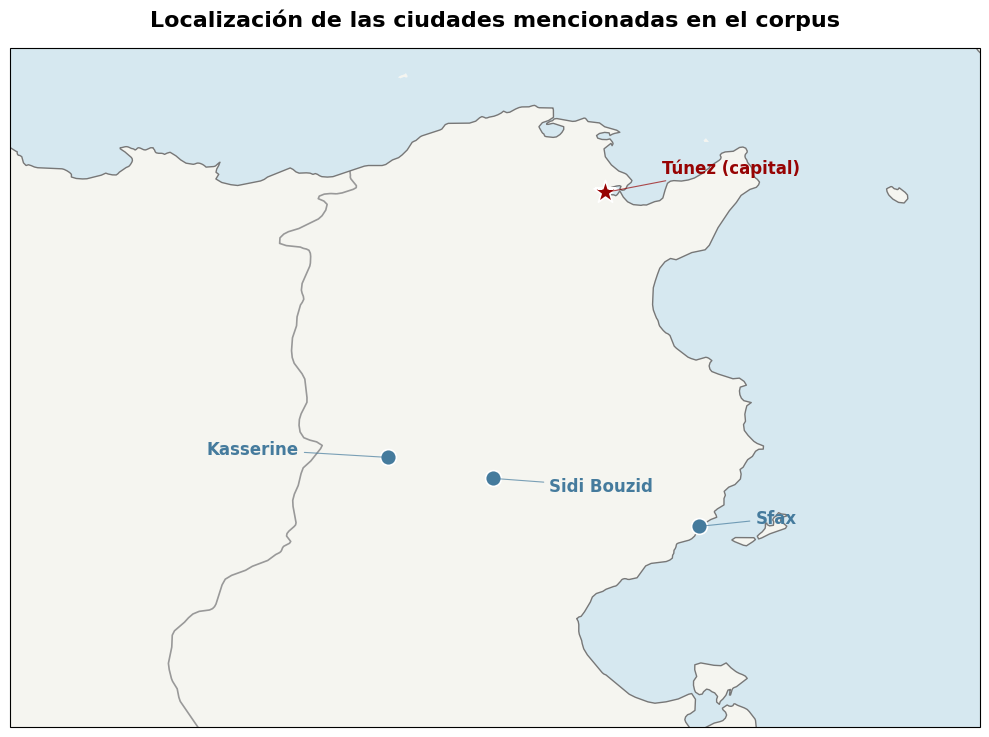

In [119]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ciudades_mapa = {
    "Túnez (capital)": (36.8065, 10.1815),
    "Sidi Bouzid": (35.0381, 9.4858),
    "Kasserine": (35.1676, 8.8365),
    "Sfax": (34.7406, 10.7603),
}

# Desplazamiento manual de cada etiqueta (en grados), para que no se solapen ni con el punto ni entre ellas
offsets_etiqueta = {
    "Túnez (capital)": (0.35, 0.15),
    "Sidi Bouzid": (0.35, -0.05),
    "Kasserine": (-0.55, 0.05),
    "Sfax": (0.35, 0.05),
}

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([6.5, 12.5, 33.5, 37.7], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#F5F5F0")
ax.add_feature(cfeature.OCEAN, facecolor="#D6E8F0")
ax.add_feature(cfeature.BORDERS, edgecolor="#999999", linewidth=1.2)
ax.add_feature(cfeature.COASTLINE, edgecolor="#777777", linewidth=1)

for nombre, (lat, lon) in ciudades_mapa.items():
    es_capital = nombre == "Túnez (capital)"
    color = "#970303" if es_capital else "#457B9D"
    marker = "*" if es_capital else "o"
    size = 300 if es_capital else 130

    ax.scatter(lon, lat, s=size, color=color, marker=marker,
               edgecolor="white", linewidth=1.2, zorder=3, transform=ccrs.PlateCarree())

    dx, dy = offsets_etiqueta[nombre]
    ax.annotate(nombre, xy=(lon, lat), xytext=(lon + dx, lat + dy),
                fontsize=12, fontweight="bold", color=color,
                ha="left" if dx > 0 else "right", va="center",
                transform=ccrs.PlateCarree(),
                arrowprops=dict(arrowstyle="-", color=color, linewidth=0.8, alpha=0.7))

ax.set_title("Localización de las ciudades mencionadas en el corpus",
             fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("mapa_ciudades_tunez.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### 6. Análisis de intensidad y violencia 

 -Diccionario para medir el grado de violencia siguiendo la escala de gravedad usada en la literatura sobre violencia política

In [120]:
lexico_violencia = {
    # Nivel 1 — Tensión y movilización social (sin violencia física directa)
    "protesta": 1, "protestas": 1, "manifestación": 1, "manifestaciones": 1,
    "revuelta": 1, "revueltas": 1, "disturbios": 1, "tensión": 1, "tensiones": 1,
    "huelga": 1, "huelgas": 1, "concentración": 1, "movilización": 1,
    "disidencia": 1, "descontento": 1, "malestar social": 1,

    # Nivel 2 — Coerción y represión estatal (fuerza sin resultado letal)
    "represión": 2, "reprimir": 2, "toque de queda": 2, "detenido": 2, "detenidos": 2,
    "detenciones": 2, "arresto": 2, "arrestos": 2, "heridos": 2, "herido": 2,
    "cargas policiales": 2, "gases lacrimógenos": 2, "brutalidad policial": 2,
    "tortura": 2, "torturas": 2, "exilio": 2, "censura": 2, "prisión": 2,
    "desaparición forzada": 2, "coacción": 2,

    # Nivel 3 — Violencia armada organizada
    "ejército": 3, "militares": 3, "milicia": 3, "milicias": 3, "insurrección": 3,
    "golpe de estado": 3, "guerrilla": 3, "enfrentamiento armado": 3,
    "francotirador": 3, "francotiradores": 3, "asedio": 3, "saqueo": 3, "saqueos": 3,

    # Nivel 4 — Violencia letal explícita
    "disparo": 4, "disparos": 4, "muerto": 4, "muertos": 4, "muerte": 4,
    "asesinato": 4, "asesinatos": 4, "inmolación": 4, "inmolarse": 4,
    "masacre": 4, "ejecución": 4, "ejecuciones": 4, "genocidio": 4,
    "magnicidio": 4, "atentado": 4, "víctimas mortales": 4,
}

- Cálculo del índice de violencia: Calcular el score por artículo

In [121]:
def calcular_score_violencia(texto, lexico):
    texto = str(texto).lower()

    # Los tokens para normalizar (densidad = score / nº de palabras)
    total_tokens = len(re.findall(r"\b[a-záéíóúüñ]+\b", texto))
    if total_tokens == 0:
        return 0

    # Cada término del léxico se busca como expresión completa sobre el texto entero,
    # no palabra por palabra -> las expresiones de varias palabras SÍ se cuentan
    score = 0
    for termino, peso in lexico.items():
        patron = r"\b" + re.escape(termino) + r"\b"
        n_apariciones = len(re.findall(patron, texto))
        score += n_apariciones * peso

    return (score / total_tokens) * 100

df_analisis["score_violencia"] = df_analisis["cuerpo_noticia"].apply(
    lambda t: calcular_score_violencia(t, lexico_violencia))

In [122]:
n_toque_queda = df_analisis["cuerpo_noticia"].str.lower().str.contains(r"\btoque de queda\b", regex=True).sum()
print(f"Artículos con 'toque de queda': {n_toque_queda}")
print("media de score_violencia:", df_analisis["score_violencia"].mean())

Artículos con 'toque de queda': 25
media de score_violencia: 2.6160867743889282


In [123]:
# Cogemos el primer artículo que contiene la expresión, y vemos su score
ejemplo = df_analisis[
    df_analisis["cuerpo_noticia"].str.lower().str.contains(r"\btoque de queda\b", regex=True)
].iloc[0]

print("Score de violencia de este artículo:", ejemplo["score_violencia"])
print("Fase:", ejemplo["periodo_fase"])

# Y comprobamos manualmente: ¿cuántas veces aparece "toque de queda" en su cuerpo?
import re
n_en_este_articulo = len(re.findall(r"\btoque de queda\b", ejemplo["cuerpo_noticia"].lower()))
print("Nº de veces que aparece 'toque de queda' en este artículo:", n_en_este_articulo)

Score de violencia de este artículo: 1.3440860215053763
Fase: Periodo post-electoral
Nº de veces que aparece 'toque de queda' en este artículo: 1


### GRÁFICO Análisis de la intensidad de violencia a lo largo del conflicto

¿Qué fase fue narrada con mayor intensidad de violencia?

/var/folders/qf/7t2996hn51n32dnx304cpkcm0000gn/T/ipykernel_25062/1931703276.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.100, 1])


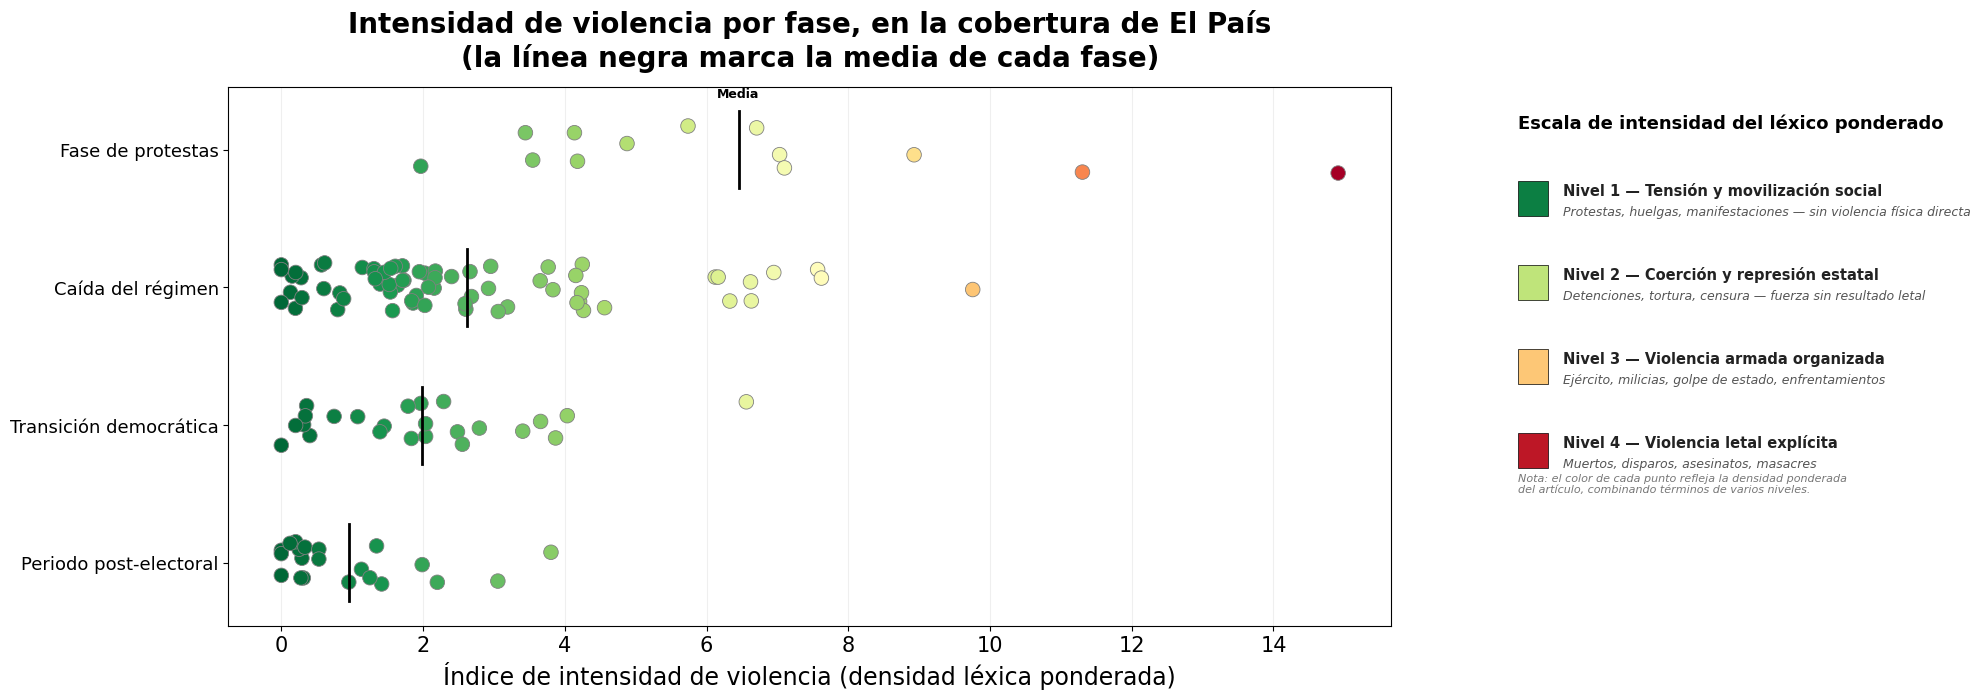

In [124]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import numpy as np

orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]
cmap_base = plt.cm.RdYlGn_r
norm = mcolors.Normalize(vmin=df_analisis["score_violencia"].min(), vmax=df_analisis["score_violencia"].max())

fig, ax = plt.subplots(figsize=(15, 7))
np.random.seed(42)

for i, fase in enumerate(orden_fases):
    subset = df_analisis[df_analisis["periodo_fase"] == fase]
    y_jitter = i + np.random.uniform(-0.18, 0.18, size=len(subset))
    colores = [cmap_base(norm(v)) for v in subset["score_violencia"]]

    ax.scatter(subset["score_violencia"], y_jitter, color=colores, s=110,
               edgecolor="grey", linewidth=0.6, zorder=3)

    media_fase = subset["score_violencia"].mean()
    ax.plot([media_fase, media_fase], [i - 0.28, i + 0.28], color="black", linewidth=2, zorder=4)
    if i == 0:
        ax.text(media_fase, i - 0.38, "Media", ha="center", fontsize=9, fontweight="bold", color="black")

ax.set_yticks(range(len(orden_fases)))
ax.set_yticklabels(orden_fases, fontsize=13)
ax.invert_yaxis()
ax.set_xlabel("Índice de intensidad de violencia (densidad léxica ponderada)", fontsize=17)  
ax.tick_params(axis="x", labelsize=15)  
ax.set_title("Intensidad de violencia por fase, en la cobertura de El País\n(la línea negra marca la media de cada fase)",
              fontsize=20, fontweight="bold", pad=15)
ax.grid(axis="x", alpha=0.2)

# --- LEYENDA: niveles conceptuales del léxico, en vez de colorbar continuo ---
niveles = [
    (1, "Tensión y movilización social", "Protestas, huelgas, manifestaciones — sin violencia física directa"),
    (2, "Coerción y represión estatal", "Detenciones, tortura, censura — fuerza sin resultado letal"),
    (3, "Violencia armada organizada", "Ejército, milicias, golpe de estado, enfrentamientos"),
    (4, "Violencia letal explícita", "Muertos, disparos, asesinatos, masacres"),]

# posiciones de color representativas de cada nivel, sobre el mismo colormap del gráfico
posiciones_color = [0.05, 0.35, 0.65, 0.95]

x_caja = 0.985
y_inicio = 0.72
alto_fila = 0.12

for (nivel, nombre, descripcion), pos_color in zip(niveles, posiciones_color):
    y = y_inicio - (nivel - 1) * alto_fila
    color = cmap_base(pos_color)

    fig.patches.append(patches.Rectangle(
        (x_caja, y - 0.025), 0.02, 0.05, transform=fig.transFigure,
        facecolor=color, edgecolor="black", linewidth=0.5
    ))
    fig.text(x_caja + 0.03, y + 0.012, f"Nivel {nivel} — {nombre}",
              fontsize=10.5, fontweight="bold", color="#222222", va="center")
    fig.text(x_caja + 0.03, y - 0.018, descripcion,
              fontsize=9, color="#555555", va="center", style="italic")

fig.text(x_caja, y_inicio + 0.10, "Escala de intensidad del léxico ponderado",
          fontsize=13, fontweight="bold", color="black")
fig.text(x_caja, y_inicio - (len(niveles) - 1) * alto_fila - 0.06,
          "Nota: el color de cada punto refleja la densidad ponderada\ndel artículo, combinando términos de varios niveles.",
          fontsize=8, color="#777777", style="italic")

plt.tight_layout(rect=[0, 0, 0.100, 1])
plt.show()

GRÁFICO: 

In [125]:
# ============================================================
# DESGLOSE POR TÉRMINO DEL LÉXICO DE VIOLENCIA (por fase)
# Usa regex sobre el texto completo, no tokenización palabra por palabra,
# para que las expresiones de varias palabras (p.ej. "toque de queda")
# se cuenten correctamente.
# ============================================================
import re
from collections import Counter

def contar_menciones_por_termino(df, columna_texto, lexico):
    """Cuenta, para cada término del léxico, cuántas veces aparece en el corpus."""
    conteos = Counter()
    for termino in lexico:
        patron = re.compile(r"\b" + re.escape(termino) + r"\b")
        for texto in df[columna_texto].dropna():
            n = len(patron.findall(str(texto).lower()))
            if n:
                conteos[termino] += n
    return conteos

def top_terminos_violencia_por_fase(df, columna_texto, columna_fase, lexico, orden_fases, top_n=8):
    """Top N términos del léxico de violencia más mencionados, fase a fase."""
    filas = []
    for fase in orden_fases:
        subset = df[df[columna_fase] == fase]
        conteos = contar_menciones_por_termino(subset, columna_texto, lexico)
        for termino, freq in conteos.most_common(top_n):
            filas.append({"fase": fase, "termino": termino, "frecuencia": freq, "nivel": lexico[termino]})
    return pd.DataFrame(filas)

df_top_violencia = top_terminos_violencia_por_fase(
    df_analisis, "cuerpo_noticia", "periodo_fase", lexico_violencia, orden_fases, top_n=8
)
df_top_violencia

,fase,termino,frecuencia,nivel
0,Fase de protestas,protestas,25,1
1,Fase de protestas,muertos,24,4
2,Fase de protestas,revuelta,16,1
3,Fase de protestas,manifestaciones,14,1
4,Fase de protestas,disturbios,10,1
5,Fase de protestas,toque de queda,10,2
6,Fase de protestas,detenidos,10,2
7,Fase de protestas,ejército,10,3
8,Caída del régimen,revuelta,84,1
9,Caída del régimen,protestas,70,1


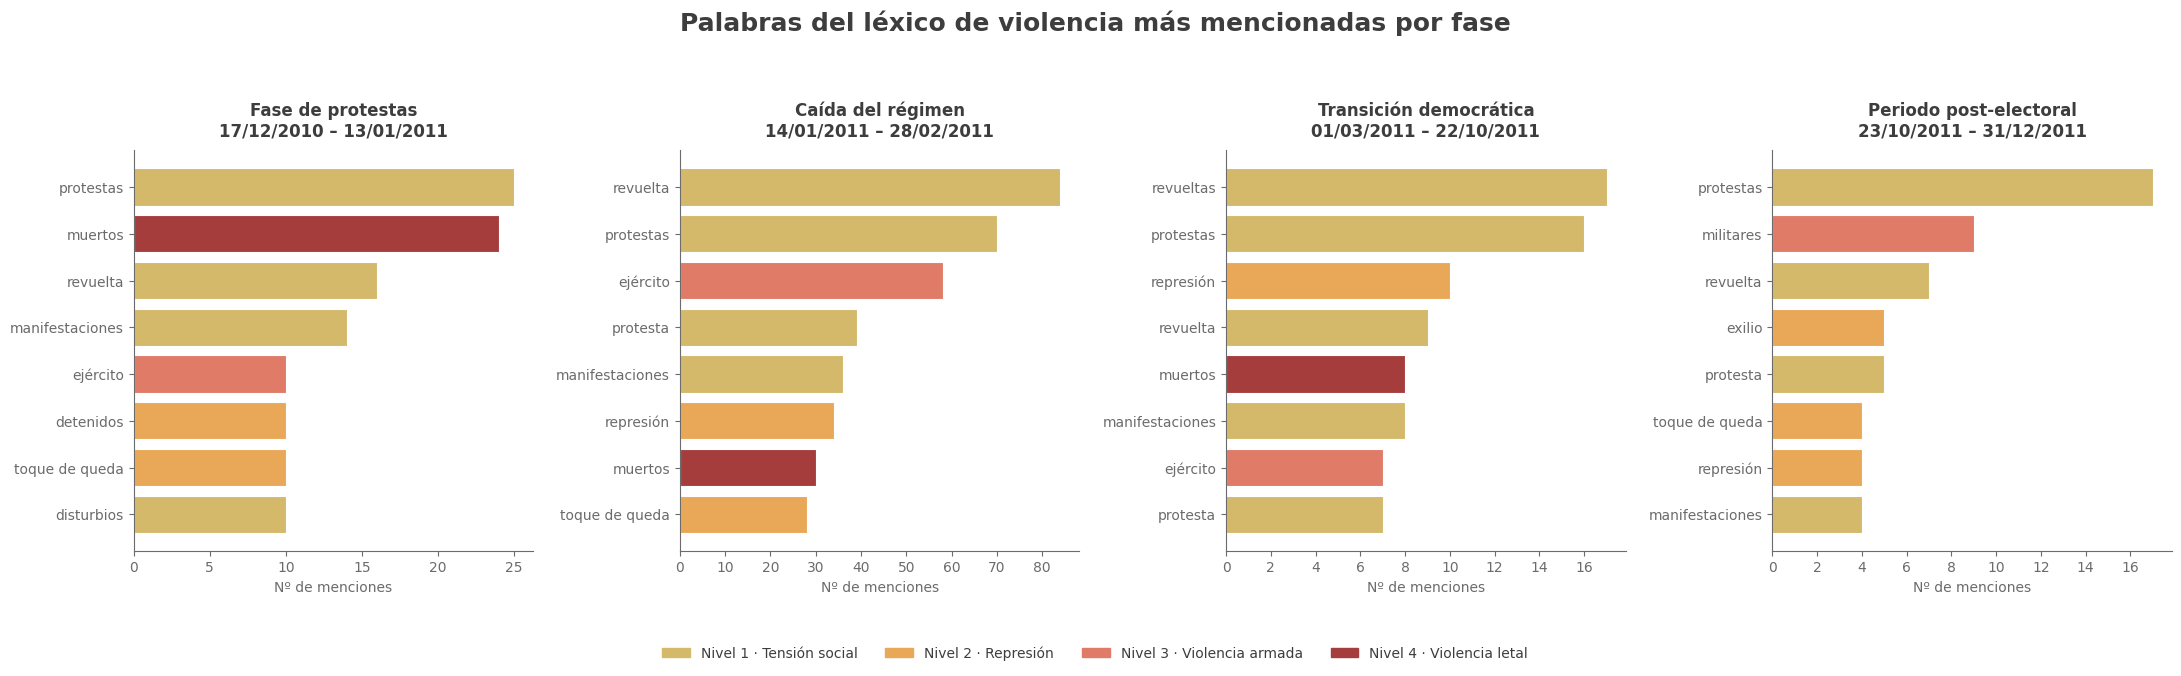

In [126]:
import matplotlib.pyplot as plt

# ---- Paleta corporativa por nivel de gravedad (la misma que en los otros gráficos de violencia) ----
colores_nivel = {1: "#D4B96A", 2: "#E8A857", 3: "#E07B68", 4: "#A63D3D"}
COLOR_TEXTO = "#3D3D3D"
COLOR_GRIS = "#6B6B6B"

FASES_FECHAS = {
    "Fase de protestas": "17/12/2010 – 13/01/2011",
    "Caída del régimen": "14/01/2011 – 28/02/2011",
    "Transición democrática": "01/03/2011 – 22/10/2011",
    "Periodo post-electoral": "23/10/2011 – 31/12/2011",
}

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.patch.set_facecolor("white")

for ax, fase in zip(axes, orden_fases):
    ax.set_facecolor("white")
    subset = df_top_violencia[df_top_violencia["fase"] == fase].sort_values("frecuencia")
    colores = [colores_nivel[n] for n in subset["nivel"]]

    ax.barh(subset["termino"], subset["frecuencia"], color=colores, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{fase}\n{FASES_FECHAS[fase]}", fontsize=12, fontweight="bold", color=COLOR_TEXTO, pad=10)
    ax.set_xlabel("Nº de menciones", fontsize=10, color=COLOR_GRIS)
    ax.tick_params(colors=COLOR_GRIS)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(COLOR_GRIS)

# Leyenda única de niveles, compartida por los 4 paneles
handles = [plt.Rectangle((0, 0), 1, 1, color=colores_nivel[n]) for n in [1, 2, 3, 4]]
etiquetas = ["Nivel 1 · Tensión social", "Nivel 2 · Represión",
            "Nivel 3 · Violencia armada", "Nivel 4 · Violencia letal"]
fig.legend(handles, etiquetas, loc="upper center", bbox_to_anchor=(0.5, 0.02),
          ncol=4, fontsize=10, frameon=False, labelcolor=COLOR_TEXTO)

fig.suptitle("Palabras del léxico de violencia más mencionadas por fase",
             fontsize=18, fontweight="bold", color=COLOR_TEXTO, y=1.06)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [127]:
# ¿Cuántos artículos distintos mencionan "muertos" en la Fase de protestas,
# y cuál es la distribución de menciones por artículo?
subset = df_analisis[df_analisis["periodo_fase"] == "Fase de protestas"]
menciones_por_articulo = subset["cuerpo_noticia"].str.lower().str.count(r"\bmuertos\b")
print("Artículos que mencionan 'muertos':", (menciones_por_articulo > 0).sum(), "de", len(subset))
print(menciones_por_articulo[menciones_por_articulo > 0].sort_values(ascending=False))

Artículos que mencionan 'muertos': 9 de 13
51    7
22    6
25    3
36    2
46    2
33    1
79    1
91    1
97    1
Name: cuerpo_noticia, dtype: int64


- Comprobación de cual es el término + representativo de cada nivel

In [128]:
print("Término representativo de cada nivel:", top1_por_nivel)

NameError: name 'top1_por_nivel' is not defined

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import re

colores_nivel = {1: "#D4B96A", 2: "#E8A857", 3: "#E07B68", 4: "#A63D3D"}
COLOR_TEXTO = "#3D3D3D"
COLOR_GRIS = "#6B6B6B"

FASES_FECHAS = {
    "Fase de protestas": "17/12/2010 – 13/01/2011",
    "Caída del régimen": "14/01/2011 – 28/02/2011",
    "Transición democrática": "01/03/2011 – 22/10/2011",
    "Periodo post-electoral": "23/10/2011 – 31/12/2011",
}
etiquetas_fases = [f"{f}<br><sup>{FASES_FECHAS[f]}</sup>" for f in orden_fases]

# ---- Paso 1: % de artículos que mencionan cada término, en TODO el corpus (no por fase) ----
def pct_global_por_termino(df, columna_texto, lexico):
    filas = []
    for termino, nivel in lexico.items():
        patron = r"\b" + re.escape(termino) + r"\b"
        n = df[columna_texto].str.lower().str.contains(patron, regex=True).sum()
        filas.append({"termino": termino, "nivel": nivel, "porcentaje_global": n / len(df) * 100})
    return pd.DataFrame(filas)

df_global = pct_global_por_termino(df_analisis, "cuerpo_noticia", lexico_violencia)

# ---- Paso 2: el término más mencionado (top-1) de cada nivel, en todo el corpus ----
top1_por_nivel = (
    df_global.sort_values("porcentaje_global", ascending=False)
    .groupby("nivel")
    .head(1)
    .set_index("nivel")["termino"]
    .to_dict()
)
print("Término representativo de cada nivel:", top1_por_nivel)

# ---- Paso 3: evolución de esos 4 términos, fase a fase ----
def pct_por_fase(df, columna_texto, columna_fase, termino, orden_fases):
    patron = r"\b" + re.escape(termino) + r"\b"
    filas = []
    for fase in orden_fases:
        subset = df[df[columna_fase] == fase]
        n = subset[columna_texto].str.lower().str.contains(patron, regex=True).sum()
        filas.append({"fase": fase, "porcentaje": n / len(subset) * 100 if len(subset) else 0})
    return pd.DataFrame(filas)

# ---- Paso 4: gráfico de líneas, una por nivel, con su término representativo ----
fig = go.Figure()

for nivel in [1, 2, 3, 4]:
    termino = top1_por_nivel[nivel]
    df_evol = pct_por_fase(df_analisis, "cuerpo_noticia", "periodo_fase", termino, orden_fases)

    fig.add_trace(go.Scatter(
        x=orden_fases, y=df_evol["porcentaje"],
        mode="lines+markers+text",
        name=f"Nivel {nivel} · {termino}",
        line=dict(color=colores_nivel[nivel], width=4),
        marker=dict(size=11, color=colores_nivel[nivel]),
        text=[f"{v:.0f}%" for v in df_evol["porcentaje"]],
        textposition="top center",
        textfont=dict(size=11, color=colores_nivel[nivel]),
    ))

fig.update_layout(
    title=dict(text="Evolución del término más representativo de cada nivel de violencia",
              font=dict(size=22, color=COLOR_TEXTO)),
    xaxis_title="", yaxis_title="% de artículos que mencionan el término",
    legend_title="Nivel de gravedad · término",
    height=600, width=1300,
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(color=COLOR_TEXTO),
    legend=dict(font=dict(color=COLOR_TEXTO)),
)
fig.update_xaxes(tickvals=orden_fases, ticktext=etiquetas_fases, tickfont=dict(color=COLOR_GRIS))
fig.update_yaxes(tickfont=dict(color=COLOR_GRIS), gridcolor="rgba(200,200,200,0.35)")
fig.show()

Término representativo de cada nivel: {1: 'revuelta', 2: 'represión', 3: 'ejército', 4: 'muertos'}


### 7. ANÁLISIS CASUÍSTICO (MÉTODO KWIC)

7.1 DICCIONARIO DE CAMPOS SEMÁNTICOS 

In [ ]:
# ============================================================
# DICCIONARIO DE CAMPOS SEMÁNTICOS 
# ============================================================
diccionario_campos_semanticos = {
    "corrupción": [
        r"\bcorrupt\w*\b", r"\bsoborno\w*\b", r"\bnepotismo\b", r"\bmalversaci[oó]n\w*\b",
        r"\bfamilia (de )?(ben ali|trabelsi)\b", r"\bclan (trabelsi|familiar)\b",
        r"\benriquecimiento il[ií]cito\b", r"\bclientelismo\b",
        r"\babuso de poder\b", r"\bapropiaci[oó]n de bienes\b", r"\bfortuna\b", r"\bprivilegios\b"
    ],
    "represión": [
        r"\brepresi[oó]n\b", r"\brepresiv\w*\b", r"\btortura\w*\b", r"\bcensura\b",
        r"\bpolic[ií]a pol[ií]tica\b", r"\bestado policial\b", r"\bcontrol policial\b",
        r"\bpresos? pol[ií]ticos?\b", r"\bpersecuci[oó]n pol[ií]tica\b",
        r"\bviolaci[oó]n(es)? de derechos humanos\b", r"\bderechos humanos\b",
        r"\bfalta de libertad(es)?\b", r"\blibertad de expresi[oó]n\b",
        r"\bpartido [uú]nico\b", r"\bprohibici[oó]n\b"
    ],
    "desempleo": [
        r"\bdesemple\w*\b", r"\bparo\b", r"\bsin trabajo\b", r"\bfalta de empleo\b",
        r"\bj[oó]venes? (parados?|sin empleo)\b", r"\btasa de paro\b", r"\bfalta de oportunidades\b"
    ],
    "pobreza": [
        r"\bpobr\w*\b", r"\bmiseria\b", r"\bprecari\w*\b", r"\bmarginaci[oó]n\b",
        r"\bexclusi[oó]n social\b", r"\bcondiciones de vida\b", r"\bcrisis econ[oó]mica\b",
        r"\bdificultades econ[oó]micas\b"
    ],
    "precios": [
        r"\bprecios?\b", r"\bencarecimiento\b", r"\binflaci[oó]n\b", r"\balimentos b[aá]sicos\b",
        r"\b(subida|aumento)(s)? de precios\b", r"\bcoste(s)? de (la )?vida\b", r"\bcarest[ií]a\b"
    ],
    "desigualdad": [
        r"\bdesigualdad\w*\b", r"\bbrecha (social|econ[oó]mica)\b", r"\binjusticia social\b",
        r"\bélites?\b", r"\bmarginaci[oó]n econ[oó]mica\b"
    ],
}

marco_por_categoria = {
    "corrupción": "político",
    "represión": "político",
    "desempleo": "socioeconómico",
    "pobreza": "socioeconómico",
    "precios": "socioeconómico",
    "desigualdad": "socioeconómico",
}

In [ ]:
# ============================================================
# 2) CONTEO POR CATEGORÍA EN CADA ARTÍCULO
# ============================================================
import re
import pandas as pd

def contar_categoria(texto, patrones):
    texto = str(texto).lower()
    return sum(len(re.findall(patron, texto)) for patron in patrones)

for categoria, patrones in diccionario_campos_semanticos.items():
    df_analisis[f"score_{categoria}"] = df_analisis["cuerpo_noticia"].apply(
        lambda t: contar_categoria(t, patrones)
    )

columnas_categorias = [f"score_{c}" for c in diccionario_campos_semanticos]
df_analisis[columnas_categorias].sum().sort_values(ascending=False)

score_represión      160
score_desempleo       65
score_corrupción      49
score_pobreza         43
score_precios         26
score_desigualdad     15
dtype: int64

In [ ]:
# ============================================================
# 3) AUDITORÍA DE TÉRMINOS — revisar qué está capturando cada patrón
# ============================================================
def auditar_categoria(categoria, patrones):
    print(f"\n=== {categoria.upper()} ===")
    for patron in patrones:
        coincidencias = df_analisis["cuerpo_noticia"].str.lower().str.findall(patron)
        total = coincidencias.apply(len).sum()
        if total > 0:
            idx_ejemplo = coincidencias[coincidencias.apply(len) > 0].index[0]
            fragmento = str(df_analisis.loc[idx_ejemplo, "cuerpo_noticia"])[:150]
            print(f"  '{patron}' → {total} veces | ej: ...{fragmento}...")
        else:
            print(f"  '{patron}' → 0 veces (revisar si el patrón es correcto o si el término no aparece en el corpus)")

for categoria, patrones in diccionario_campos_semanticos.items():
    auditar_categoria(categoria, patrones)


=== CORRUPCIÓN ===
  '\bcorrupt\w*\b' → 13 veces | ej: ...La llama que incendió Túnez La inmolación del vendedor de frutas Mohamed Bouazizi el pasado 17 de diciembre en la olvidada ciudad tunecina de Sidi bou...
  '\bsoborno\w*\b' → 1 veces | ej: ...El nuevo presidente de Túnez encarga un Gobierno de coalición ante el temor al caos Fued Mebaza, jura el cargo tras una resolución del Consejo Constit...
  '\bnepotismo\b' → 6 veces | ej: ...Nuevas elecciones en el golfo Pérsico a la sombra de la primavera árabe Los comicios de hoy en Bahréin y Emiratos Árabes Unidos ponen al descubierto l...
  '\bmalversaci[oó]n\w*\b' → 3 veces | ej: ...Comienza el juicio contra el expresidente tunecino Ben Alí El exmandatario niega en un comunicado que mandase disparar contra los manifestantes.- Es e...
  '\bfamilia (de )?(ben ali|trabelsi)\b' → 9 veces | ej: ...La llama que incendió Túnez La inmolación del vendedor de frutas Mohamed Bouazizi el pasado 17 de diciembre en la olvidada ciudad tunecina de Si

In [ ]:
# ============================================================
# 4) TOP 3 TÉRMINOS POR CATEGORÍA
# ============================================================
def top_3_terminos(patrones):
    conteos = {}
    for patron in patrones:
        total = df_analisis["cuerpo_noticia"].str.lower().str.count(patron).sum()
        conteos[patron] = total
    return sorted(conteos.items(), key=lambda x: x[1], reverse=True)[:3]

for categoria, patrones in diccionario_campos_semanticos.items():
    print(f"{categoria}: {top_3_terminos(patrones)}")

corrupción: [('\\bcorrupt\\w*\\b', np.int64(13)), ('\\bfamilia (de )?(ben ali|trabelsi)\\b', np.int64(9)), ('\\babuso de poder\\b', np.int64(7))]
represión: [('\\brepresi[oó]n\\b', np.int64(56)), ('\\bderechos humanos\\b', np.int64(42)), ('\\btortura\\w*\\b', np.int64(14))]
desempleo: [('\\bdesemple\\w*\\b', np.int64(31)), ('\\bparo\\b', np.int64(26)), ('\\bfalta de oportunidades\\b', np.int64(4))]
pobreza: [('\\bpobr\\w*\\b', np.int64(24)), ('\\bprecari\\w*\\b', np.int64(6)), ('\\bcrisis econ[oó]mica\\b', np.int64(6))]
precios: [('\\bprecios?\\b', np.int64(18)), ('\\balimentos b[aá]sicos\\b', np.int64(3)), ('\\bcarest[ií]a\\b', np.int64(2))]
desigualdad: [('\\bélites?\\b', np.int64(12)), ('\\binjusticia social\\b', np.int64(2)), ('\\bdesigualdad\\w*\\b', np.int64(1))]


In [ ]:
# ============================================================
# 5) COMPARACIÓN POR FASE
# ============================================================
orden_fases = ["Fase de protestas", "Caída del régimen", "Transición democrática", "Periodo post-electoral"]

tabla_causas_fase = df_analisis.groupby("periodo_fase")[columnas_categorias].sum().reindex(orden_fases)
tabla_causas_fase.columns = [c.replace("score_", "") for c in tabla_causas_fase.columns]
tabla_causas_fase

,corrupción,represión,desempleo,pobreza,precios,desigualdad
periodo_fase,,,,,,
Fase de protestas,0,16,14,2,10,0
Caída del régimen,35,90,39,30,13,11
Transición democrática,12,31,4,2,1,3
Periodo post-electoral,2,23,8,9,2,1


In [ ]:
# ============================================================
# 6) CAMPO SEMÁNTICO DOMINANTE POR ARTÍCULO Y POR FASE
# ============================================================
df_analisis["campo_dominante"] = df_analisis[columnas_categorias].idxmax(axis=1).str.replace("score_", "")

sin_marco = df_analisis[columnas_categorias].sum(axis=1) == 0
df_analisis.loc[sin_marco, "campo_dominante"] = None

tabla_dominante_fase = pd.crosstab(df_analisis["periodo_fase"], df_analisis["campo_dominante"]).reindex(orden_fases)
tabla_dominante_fase

campo_dominante,corrupción,desempleo,desigualdad,pobreza,precios,represión
periodo_fase,,,,,,
Fase de protestas,0,4,0,1,2,5
Caída del régimen,12,6,1,4,1,30
Transición democrática,5,1,0,0,0,12
Periodo post-electoral,1,2,0,1,0,11


In [ ]:
# ============================================================
# 7) MACRO-MARCOS: político vs. socioeconómico
# ============================================================
categorias_politico = [f"score_{c}" for c, m in marco_por_categoria.items() if m == "político"]
categorias_socioeconomico = [f"score_{c}" for c, m in marco_por_categoria.items() if m == "socioeconómico"]

df_analisis["score_politico"] = df_analisis[categorias_politico].sum(axis=1)
df_analisis["score_socioeconomico"] = df_analisis[categorias_socioeconomico].sum(axis=1)

tabla_marcos_fase = df_analisis.groupby("periodo_fase")[["score_politico", "score_socioeconomico"]].sum().reindex(orden_fases)
tabla_marcos_fase["peso_relativo_socioeconomico_%"] = (
    tabla_marcos_fase["score_socioeconomico"] /
    (tabla_marcos_fase["score_politico"] + tabla_marcos_fase["score_socioeconomico"]) * 100
).round(1)
tabla_marcos_fase

,score_politico,score_socioeconomico,peso_relativo_socioeconomico_%
periodo_fase,,,
Fase de protestas,16,26,61.9
Caída del régimen,125,93,42.7
Transición democrática,43,10,18.9
Periodo post-electoral,25,20,44.4


**Nota metodológica — normalización del porcentaje por fase**

El porcentaje se calcula **dentro de cada fase por separado**: se divide entre la suma de 
menciones políticas + socioeconómicas de esa misma fase, no entre el total del corpus. 
Por eso cada barra suma 100% de forma independiente, sin importar cuántos artículos 
tenga la fase detrás (68 en Caída del régimen vs. 13 en Transición democrática, por ejemplo).

Esto evita que una fase con más artículos "gane" el reparto solo por volumen — los porcentajes 
reflejan el peso *proporcional* de cada marco dentro de su propia fase, no el volumen bruto 
de menciones. Se verificó además que el número total de menciones detrás de cada porcentaje 
(42–218 según la fase) se mantiene en un rango razonable en las cuatro fases, por lo que 
ninguna proporción está sostenida por una muestra anómalamente pequeña.

In [ ]:
import plotly.express as px
import pandas as pd

# ---- Paleta corporativa: morado (político) + ocre (socioeconómico) ----
colores_marco = {"Marco político\n(corrupción + represión)": "#9482BA",
                  "Marco socioeconómico\n(desempleo + pobreza + precios + desigualdad)": "#D4B96A"}
COLOR_TEXTO = "#3D3D3D"
COLOR_GRIS = "#6B6B6B"

FASES_FECHAS = {
    "Fase de protestas": "17/12/2010 – 13/01/2011",
    "Caída del régimen": "14/01/2011 – 28/02/2011",
    "Transición democrática": "01/03/2011 – 22/10/2011",
    "Periodo post-electoral": "23/10/2011 – 31/12/2011",
}
etiquetas_fase_fecha = [f"{f}<br><sup>{FASES_FECHAS[f]}</sup>" for f in orden_fases]

# ---- Proporciones (% del peso total de causas mencionadas, por fase) ----
proporciones = tabla_marcos_fase[["score_politico", "score_socioeconomico"]].div(
    tabla_marcos_fase[["score_politico", "score_socioeconomico"]].sum(axis=1), axis=0
) * 100

# Formato largo, con nombres ya traducidos para que la leyenda salga legible
df_marco = proporciones.reset_index().melt(
    id_vars="periodo_fase", var_name="marco", value_name="porcentaje"
)
df_marco["marco"] = df_marco["marco"].map({
    "score_politico": "Marco político\n(corrupción + represión)",
    "score_socioeconomico": "Marco socioeconómico\n(desempleo + pobreza + precios + desigualdad)",
})
df_marco["etiqueta"] = df_marco["porcentaje"].round(0).astype(int).astype(str) + "%"

fig = px.bar(
    df_marco, x="periodo_fase", y="porcentaje", color="marco",
    text="etiqueta", category_orders={"periodo_fase": orden_fases},
    color_discrete_map=colores_marco,
    title="¿Qué marco explicativo domina en cada fase: político o socioeconómico?"
)

fig.update_traces(textposition="inside", textfont=dict(size=14, color="white", weight="bold"))
fig.update_layout(
    barmode="stack",
    xaxis_title="", yaxis_title="% del peso total de causas mencionadas",
    legend_title="", height=650, width=950,
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(color=COLOR_TEXTO),
    title_font=dict(size=18, color=COLOR_TEXTO),
    legend=dict(orientation="h", yanchor="bottom", y=-0.35, xanchor="center", x=0.5,
               font=dict(color=COLOR_TEXTO)),
)
fig.update_xaxes(tickvals=orden_fases, ticktext=etiquetas_fase_fecha, tickfont=dict(color=COLOR_GRIS))
fig.update_yaxes(tickfont=dict(color=COLOR_GRIS), gridcolor="rgba(200,200,200,0.35)")
fig.show()

In [ ]:
tabla_marcos_fase["total_menciones"] = tabla_marcos_fase["score_politico"] + tabla_marcos_fase["score_socioeconomico"]
tabla_marcos_fase[["total_menciones", "peso_relativo_socioeconomico_%"]]

,total_menciones,peso_relativo_socioeconomico_%
periodo_fase,,
Fase de protestas,42,61.9
Caída del régimen,218,42.7
Transición democrática,53,18.9
Periodo post-electoral,45,44.4


conclusión: el 81% de Transición democrática no es un artefacto de muestra pequeña — tiene 53 menciones totales detrás, un volumen razonable, comparable al de Fase de protestas (42) y Periodo post-electoral (45). No es un solo artículo aislado inflando el porcentaje; es un patrón sostenido por un número de menciones similar al de las otras fases "normales".

In [ ]:
# Verificación explícita del patrón "U invertida" en el marco político
print(tabla_marcos_fase[["peso_relativo_socioeconomico_%"]])

# Diferencia entre fase inicial y fase de pico político, para cuantificar el desplazamiento
socioeconomico_inicio = tabla_marcos_fase.loc["Fase de protestas", "peso_relativo_socioeconomico_%"]
socioeconomico_pico_politico = tabla_marcos_fase.loc["Transición democrática", "peso_relativo_socioeconomico_%"]
socioeconomico_final = tabla_marcos_fase.loc["Periodo post-electoral", "peso_relativo_socioeconomico_%"]

print(f"Peso socioeconómico en el origen: {socioeconomico_inicio}%")
print(f"Peso socioeconómico en el pico político (Transición): {socioeconomico_pico_politico}%")
print(f"Peso socioeconómico al final: {socioeconomico_final}%")
print(f"Caída del peso socioeconómico entre origen y pico político: {socioeconomico_inicio - socioeconomico_pico_politico:.1f} puntos")
print(f"Recuperación del peso socioeconómico entre pico político y final: {socioeconomico_final - socioeconomico_pico_politico:.1f} puntos")

                        peso_relativo_socioeconomico_%
periodo_fase                                          
Fase de protestas                                 61.9
Caída del régimen                                 42.7
Transición democrática                            18.9
Periodo post-electoral                            44.4
Peso socioeconómico en el origen: 61.9%
Peso socioeconómico en el pico político (Transición): 18.9%
Peso socioeconómico al final: 44.4%
Caída del peso socioeconómico entre origen y pico político: 43.0 puntos
Recuperación del peso socioeconómico entre pico político y final: 25.5 puntos
